In [535]:
import os

import glob

import numpy as np

import matplotlib
import matplotlib.pyplot as plt

import seaborn as sns

import pandas as pd

import sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight

import imblearn

from xgboost import XGBClassifier



print(np.__version__)
print(matplotlib.__version__)
print(sns.__version__)
print(pd.__version__)
print(sklearn.__version__)
print(imblearn.__version__)
print(xgboost.__version__)

2.4.4
3.10.8
0.13.2
3.0.2
1.9.0
0.14.2
3.4.0


# Reading Dataset

In [3]:
path = r"E:\Final Project\Adaptive_Cyber_Immune_Deception_Platform\AI\Datasets2"
files = glob.glob(os.path.join(path, "*.csv"))
dss = []
for file in files:
    print("loading: ", file)
    ds = pd.read_csv(file)
    dss.append(ds)
cicids = pd.concat(dss, ignore_index=True)
print("All files loaded")

loading:  E:\Final Project\Adaptive_Cyber_Immune_Deception_Platform\AI\Datasets2\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
loading:  E:\Final Project\Adaptive_Cyber_Immune_Deception_Platform\AI\Datasets2\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
loading:  E:\Final Project\Adaptive_Cyber_Immune_Deception_Platform\AI\Datasets2\Friday-WorkingHours-Morning.pcap_ISCX.csv
loading:  E:\Final Project\Adaptive_Cyber_Immune_Deception_Platform\AI\Datasets2\Monday-WorkingHours.pcap_ISCX.csv
loading:  E:\Final Project\Adaptive_Cyber_Immune_Deception_Platform\AI\Datasets2\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
loading:  E:\Final Project\Adaptive_Cyber_Immune_Deception_Platform\AI\Datasets2\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
loading:  E:\Final Project\Adaptive_Cyber_Immune_Deception_Platform\AI\Datasets2\Tuesday-WorkingHours.pcap_ISCX.csv
loading:  E:\Final Project\Adaptive_Cyber_Immune_Deception_Platform\AI\Datasets2\Wednesday-workingHours.p

# Preprocessing

## Cleaning Column Names

In [4]:
print(cicids.columns[0: 10])
cicids.columns = cicids.columns.str.strip()
cicids.columns = cicids.columns.str.replace(' ', '_')
cicids.columns = cicids.columns.str.lower()
print(cicids.columns[0: 10])

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std'],
      dtype='str')
Index(['destination_port', 'flow_duration', 'total_fwd_packets',
       'total_backward_packets', 'total_length_of_fwd_packets',
       'total_length_of_bwd_packets', 'fwd_packet_length_max',
       'fwd_packet_length_min', 'fwd_packet_length_mean',
       'fwd_packet_length_std'],
      dtype='str')


## Cleaning Label Names

In [5]:
print(cicids['label'].value_counts())
cicids['label'] = cicids['label'].str.lower()
print(cicids['label'].value_counts())
cicids['label'] = cicids['label'].str.replace(' � ', '-')
print(cicids['label'].value_counts())

label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
label
benign                        2273097
dos hulk                       231073
portscan                       158930
ddos                           128027
dos goldeneye                   10293
ftp-patator                      7938
ssh-patator                      5897
dos slowloris                    5796
dos slowhttptest                 5499
bot                              1966
web attack �

## Deleting unreasonable rows

### where flow_duration has negative values

In [6]:
len(cicids[cicids['flow_duration'] < 0])

115

In [7]:
cicids = cicids[cicids['flow_duration'] >= 0]

In [8]:
len(cicids[cicids['flow_duration'] < 0])

0

### where flow_iat_min has negative values

In [9]:
len(cicids[cicids['flow_iat_min'] < 0])

2776

In [10]:
cicids = cicids[cicids['flow_iat_min'] >= 0]

In [11]:
len(cicids[cicids['flow_duration'] < 0])

0

### where fwd_header_length has negative values

In [12]:
len(cicids[cicids['fwd_header_length'] < 0])

35

In [13]:
cicids = cicids[cicids['fwd_header_length'] >= 0]

In [14]:
len(cicids[cicids['fwd_header_length'] < 0])

0

In [15]:
len(cicids[cicids['bwd_header_length'] < 0])

0

In [16]:
cicids = cicids[cicids['bwd_header_length'] >= 0]

In [17]:
len(cicids[cicids['bwd_header_length'] < 0])

0

## Droping unreasonable columns

In [18]:
features = ['bwd_avg_packets/bulk','fwd_avg_packets/bulk','bwd_avg_bytes/bulk', 
            'fwd_avg_bytes/bulk', 'fwd_avg_bulk_rate', 'bwd_avg_bulk_rate']
for feature in features:
    print(len(cicids[cicids[feature] == 0]) - len(cicids))
cicids = cicids.drop(columns=features)

0
0
0
0
0
0


## Adding columns for the major attacks and sub_attack

In [19]:
DoS = [
    "dos hulk",
    "dos goldeneye",
    "dos slowloris",
    "dos slowhttptest"
]
DDoS = [
    "ddos"
]
Brute_Force = [
    "ftp-patator",
    "ssh-patator"
]
Web_Attack = [
    "web attack-brute force",
    "web attack-xss",
    "web attack-sql injection"
]
Port_Scan = [
    "portscan"
]
Bot = [
    "bot"
]
Infiltration = [
    "infiltration"
]
Heartbleed = [
    "heartbleed"
]
def map_to_category(Label):
    if Label == 'benign':
        return 'benign'
    elif Label in DoS:
        return 'dos'
    elif Label in DDoS:
        return 'ddos'
    elif Label in Brute_Force:
        return "brute-force"
    elif Label in Web_Attack:
        return "web-attack"
    elif Label in Port_Scan:
        return "port-scan"
    elif Label in Bot:
        return "bot"
    elif Label in Infiltration:
        return "infiltration"
    elif Label in Heartbleed:
        return "heartbleed"
cicids['major_cat'] = cicids['label'].apply(map_to_category)
print(cicids.groupby('label')['major_cat'].value_counts())

label                     major_cat   
benign                    benign          2270365
bot                       bot                1966
ddos                      ddos             128008
dos goldeneye             dos               10288
dos hulk                  dos              230914
dos slowhttptest          dos                5499
dos slowloris             dos                5796
ftp-patator               brute-force        7934
heartbleed                heartbleed            7
infiltration              infiltration         35
portscan                  port-scan        158930
ssh-patator               brute-force        5895
web attack-brute force    web-attack         1507
web attack-sql injection  web-attack           21
web attack-xss            web-attack          652
Name: count, dtype: int64


In [20]:
cicids['sub_attack'] = cicids['label']
cicids.loc[cicids['major_cat'] == 'web-attack', 'sub_attack'] = cicids.loc[cicids['major_cat'] == 'web-attack', 'label'].str.replace('web attack-', '', regex =False)
cicids.loc[cicids['major_cat'] == 'dos', 'sub_attack'] = cicids.loc[cicids['major_cat'] == 'dos', 'label'].str.replace('dos ', '', regex=False)

print(cicids.groupby('label')[['major_cat', 'sub_attack']].value_counts())

label                     major_cat     sub_attack   
benign                    benign        benign           2270365
bot                       bot           bot                 1966
ddos                      ddos          ddos              128008
dos goldeneye             dos           goldeneye          10288
dos hulk                  dos           hulk              230914
dos slowhttptest          dos           slowhttptest        5499
dos slowloris             dos           slowloris           5796
ftp-patator               brute-force   ftp-patator         7934
heartbleed                heartbleed    heartbleed             7
infiltration              infiltration  infiltration          35
portscan                  port-scan     portscan          158930
ssh-patator               brute-force   ssh-patator         5895
web attack-brute force    web-attack    brute force         1507
web attack-sql injection  web-attack    sql injection         21
web attack-xss            web-attack

### Cleaning the sub_attack column

In [21]:
cicids.loc[cicids['major_cat'] == 'web-attack', 'sub_attack'] = cicids.loc[cicids['major_cat'] == 'web-attack', 'sub_attack'].str.replace(' ', '-', regex =False)
print(cicids.groupby('label')[['major_cat', 'sub_attack']].value_counts())

label                     major_cat     sub_attack   
benign                    benign        benign           2270365
bot                       bot           bot                 1966
ddos                      ddos          ddos              128008
dos goldeneye             dos           goldeneye          10288
dos hulk                  dos           hulk              230914
dos slowhttptest          dos           slowhttptest        5499
dos slowloris             dos           slowloris           5796
ftp-patator               brute-force   ftp-patator         7934
heartbleed                heartbleed    heartbleed             7
infiltration              infiltration  infiltration          35
portscan                  port-scan     portscan          158930
ssh-patator               brute-force   ssh-patator         5895
web attack-brute force    web-attack    brute-force         1507
web attack-sql injection  web-attack    sql-injection         21
web attack-xss            web-attack

## Add column for binary classification Normal (0) Vs. Attack (1)

In [22]:
cicids['binary_cat'] = 1
cicids.loc[cicids['major_cat'] == 'benign', 'binary_cat'] = 0

# Understanding Features

## Flow identification features
- Flow ID --> Unique identifier for a network flow, usually constructed from IP addresses, ports, protocol, etc.
- Source IP --> IP address of the machine sending the traffic.
- Source Port --> Port number used by the source machine.
- Destination IP --> IP address of the machine receiving the traffic.
- Destination Port --> Port number used by the destination machine.
- Protocol --> Network protocol, such as TCP or UDP.
- Timestamp --> Time at which the flow was recorded.
## Flow duration
- Flow Duration --> The total duration of the network flow.
## Packet count features
- Total Fwd Packets --> Number of packets sent from the source → destination.
- Total Backward Packets --> Number of packets sent from the destination → source.
## Packet length features
- Total Length of Fwd Packets
- Total Length of Bwd Packets
- Fwd Packet Length Max
- Fwd Packet Length Min
- Fwd Packet Length Mean
- Fwd Packet Length Std
- Bwd Packet Length Max
- Bwd Packet Length Min
- Bwd Packet Length Mean
- Bwd Packet Length Std
## Flow rate features
- Flow Bytes/s --> Average number of bytes transferred per second.
- Flow Packets/s --> Number of packets transmitted per second.
## Inter-arrival time (IAT) features
IAT measures the time between consecutive packets.
- Flow IAT Mean
- Flow IAT Std
- Flow IAT Max
- Flow IAT Min
- Fwd IAT Total
- Fwd IAT Mean
- Fwd IAT Std
- Fwd IAT Max
- Fwd IAT Min
- Bwd IAT Total
- Bwd IAT Mean
- Bwd IAT Std
- Bwd IAT Max
- Bwd IAT Min
## TCP flag features
These describe TCP flags observed in the flow.
- FIN Flag Count → Number of TCP packets with the FIN flag, used to terminate a TCP connection.
- SYN Flag Count → Number of TCP packets with the SYN flag, mainly used to initiate a TCP connection.
- RST Flag Count → Number of TCP packets with the RST flag, used to reset a TCP connection.
- PSH Flag Count → Number of TCP packets with the PSH flag, indicating that available data should be pushed to the receiving application.
- ACK Flag Count → Number of TCP packets with the ACK flag, used to acknowledge received data.
- URG Flag Count → Number of TCP packets with the URG flag, indicating urgent data.
- ECE Flag Count → Number of TCP packets with the ECE flag, related to Explicit Congestion Notification.
- CWR Flag Count → Number of TCP packets with the CWR flag, indicating a reduction in the TCP congestion window.
## TCP header / window features
These describe characteristics of TCP headers, segments, and initial TCP window sizes.
- Fwd Header Length / Fwd Header Length.1 (duplicated column) → The total length of packet headers in the forward direction (source → destination).
- Bwd Header Length → The total length of packet headers in the backward direction (destination → source).
- Fwd Act Data Packets / act_data_pkt_fwd (duplicated column) → The number of forward packets that contain actual data.
- Fwd Seg Size Min / min_seg_size_forward (duplicated column) → The minimum size of a TCP segment in the forward direction.
- Init_Win_bytes_forward → The initial TCP window size in the forward direction.
- Init_Win_bytes_backward → The initial TCP window size in the backward direction.
## Active/Idle features
These describe periods when the connection is actively transferring data versus periods when it is idle.
- Active Mean
- Active Std
- Active Max
- Active Min
- Idle Mean
- Idle Std
- Idle Max
- Idle Min
## Subflow features
subflow is essentially a portion of a network flow used to characterize traffic behavior.
- Subflow Fwd Packets (number of forward packets)
- Subflow Fwd Bytes (forward bytes)
- Subflow Bwd Packets (number of backward packets)
- Subflow Bwd Bytes (backward bytes)
## Bulk transfer features
These describe groups/bursts of packets transferred in bulk.
- Fwd Avg Bytes/Bulk
- Fwd Avg Packets/Bulk
- Fwd Avg Bulk Rate
- Bwd Avg Bytes/Bulk
- Bwd Avg Packets/Bulk
- Bwd Avg Bulk Rate
## Packet size statistics
These summarize packet sizes.
- Avg Packet Size
- Avg Fwd Segment Size
- Avg Bwd Segment Size
- Packet Length Variance
## Down/Up ratio
Describes the relationship between backward/downstream and forward/upstream traffic. For example, if:
- Forward traffic = 100 KB
- Backward traffic = 500 KB
the flow is heavily biased toward downstream traffic.
## Destination Port
Destination Port --> The application/service port receiving the traffic. For example
- 21  → FTP
- 22  → SSH
- 53  → DNS
- 80  → HTTP
- 443 → HTTPS
# Target
- Label --> the different attacks
- binary_label --> normal (0) Vs. attack (1) 

In [23]:
binary_features = [
    'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags',
    'fin_flag_count', 'syn_flag_count', 'rst_flag_count', 'psh_flag_count',
    'ack_flag_count', 'urg_flag_count', 'cwe_flag_count', 'ece_flag_count'
]
categorical_features = ['label', 'major_cat', 'sub_attack', 'binary_cat']
numerical_features = []
for feature in cicids.columns:
    if feature not in categorical_features and feature not in binary_features:
        numerical_features.append(feature)
numerical_features

['destination_port',
 'flow_duration',
 'total_fwd_packets',
 'total_backward_packets',
 'total_length_of_fwd_packets',
 'total_length_of_bwd_packets',
 'fwd_packet_length_max',
 'fwd_packet_length_min',
 'fwd_packet_length_mean',
 'fwd_packet_length_std',
 'bwd_packet_length_max',
 'bwd_packet_length_min',
 'bwd_packet_length_mean',
 'bwd_packet_length_std',
 'flow_bytes/s',
 'flow_packets/s',
 'flow_iat_mean',
 'flow_iat_std',
 'flow_iat_max',
 'flow_iat_min',
 'fwd_iat_total',
 'fwd_iat_mean',
 'fwd_iat_std',
 'fwd_iat_max',
 'fwd_iat_min',
 'bwd_iat_total',
 'bwd_iat_mean',
 'bwd_iat_std',
 'bwd_iat_max',
 'bwd_iat_min',
 'fwd_header_length',
 'bwd_header_length',
 'fwd_packets/s',
 'bwd_packets/s',
 'min_packet_length',
 'max_packet_length',
 'packet_length_mean',
 'packet_length_std',
 'packet_length_variance',
 'down/up_ratio',
 'average_packet_size',
 'avg_fwd_segment_size',
 'avg_bwd_segment_size',
 'fwd_header_length.1',
 'subflow_fwd_packets',
 'subflow_fwd_bytes',
 'subflow

# Exploratory Data Analysis

## Dataset Overview
- How many rows and columns are in the dataset?
- What are the data types of all columns?
- Are there missing values?
- Are there duplicated rows?
- Which columns have constant values?
- Which columns have very few unique values?

In [24]:
rows = cicids.shape[0]
print(f"Total number of rows: {rows}")
columns = cicids.shape[1]
print(f"Total number of columns: {columns}")

missging_values = cicids.isna().any().any()
print(f"is there any missing values? {missging_values}")
duplicate_values = cicids.duplicated().any()
print(f"is there any duplicated values? {duplicate_values}")

constant_values = cicids.columns[cicids.nunique() == 1]
print(f"Which columns have constant values: {constant_values.values[0]}")

unique_values = cicids.nunique()
least_5 = unique_values.nsmallest(5)
print(f"the columns that have very few unique value:")
print(least_5)

Total number of rows: 2827817
Total number of columns: 76
is there any missing values? True
is there any duplicated values? True
Which columns have constant values: bwd_psh_flags
the columns that have very few unique value:
bwd_psh_flags     1
bwd_urg_flags     1
fwd_psh_flags     2
fwd_urg_flags     2
fin_flag_count    2
dtype: int64


### Handling The Missing Values

In [25]:
print(cicids.columns[cicids.isna().any()])
print(cicids.columns[cicids.isna().any()].shape[0])
print(cicids[cicids.isna().any(axis=1)].shape[0])
print(cicids.loc[cicids['flow_bytes/s'].isna(), ['flow_duration']].sum())
print('------- Before Deleting The Rows With Missing Values ----------')
print(cicids.shape)
print('------- After Deleting The Rows With Missing Values ----------')
cicids = cicids.dropna()
print(cicids.shape)

Index(['flow_bytes/s'], dtype='str')
1
1357
flow_duration    0
dtype: int64
------- Before Deleting The Rows With Missing Values ----------
(2827817, 76)
------- After Deleting The Rows With Missing Values ----------
(2826460, 76)


### Handle The Duplicated Rows

In [26]:
print(cicids[cicids.duplicated()].index)
print(cicids.duplicated().sum())

print("--------- Before Deleting The duplicated Rows ----------")
print(cicids.shape)
print("--------- After Deleting The duplicated Rows ----------")
cicids = cicids.drop_duplicates()
print(cicids.shape)

Index([   2109,    2257,    2749,    2862,    2877,    3087,    3091,    3092,
          3103,    3374,
       ...
       2830649, 2830675, 2830685, 2830691, 2830693, 2830701, 2830725, 2830726,
       2830731, 2830733],
      dtype='int64', length=307366)
307366
--------- Before Deleting The duplicated Rows ----------
(2826460, 76)
--------- After Deleting The duplicated Rows ----------
(2519094, 76)


### Handle The Infinite Values

In [27]:
np.isinf(cicids.select_dtypes(include='number')).sum().sum()

np.int64(2422)

In [28]:
infinite_columns = np.isinf(cicids.select_dtypes(include='number')).sum()
infinite_columns[infinite_columns > 0]

flow_bytes/s      1211
flow_packets/s    1211
dtype: int64

In [29]:
cicids[np.isinf(cicids['flow_bytes/s']) | np.isinf(cicids['flow_packets/s'])]['flow_duration'].value_counts()

flow_duration
0    1211
Name: count, dtype: int64

In [30]:
cicids.loc[cicids['flow_duration'] == 0, ['flow_bytes/s','flow_packets/s']] = np.nan

In [31]:
cicids[np.isinf(cicids['flow_bytes/s']) | np.isinf(cicids['flow_packets/s'])]['flow_duration'].value_counts()

Series([], Name: count, dtype: int64)

## Target / Attack Distribution
- What is the distribution of Normal vs Attack traffic?
- Which attack types are most common?
- How severe is the class imbalance?
- Which attack types are rare?

## Class distribution
- How many records are Benign vs Attack?
- What percentage of the dataset is benign and what percentage is attack?
- Is the binary dataset balanced or imbalanced?
- Which major_cat attack type has the largest number of samples?
- Which major_cat has the fewest samples?
- Which individual sub_attack has the largest number of samples?

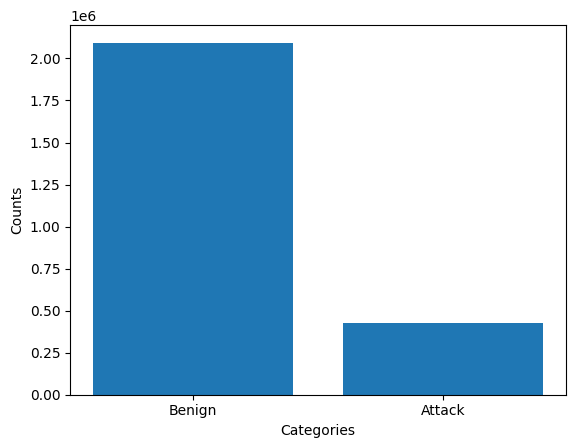

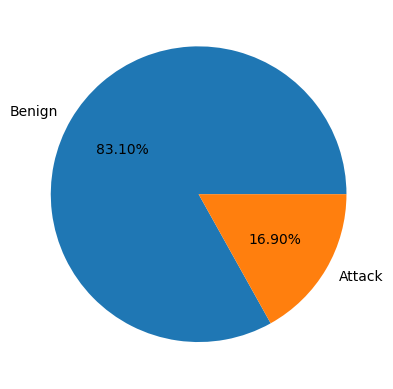

In [32]:
attacksVsBenign = cicids['binary_cat'].value_counts().sort_index()
plt.bar(['Benign', 'Attack'], attacksVsBenign)
plt.xlabel('Categories')
plt.ylabel('Counts')
plt.show()
plt.pie(attacksVsBenign, labels=['Benign', 'Attack'], autopct='%0.2f%%')
plt.show()

In [33]:
cicids['binary_cat'].value_counts()
normal_count = cicids['binary_cat'].value_counts()[0]
attack_count = cicids['binary_cat'].value_counts()[1]
print(f'the Nomral count are larger than Attack by {(normal_count - attack_count)/(normal_count + attack_count) * 100 :.2f}%')
print("then the binary dataset is imbalanced")

the Nomral count are larger than Attack by 66.20%
then the binary dataset is imbalanced


In [34]:
biggest_class = (cicids['major_cat'].value_counts().max(), cicids['major_cat'].value_counts().idxmax())
print(f"the largest major class that has the biggest number of count is \033[1m{biggest_class[1]}\033[0m with \033[1m{biggest_class[0]}\033[0m samples")

the largest major class that has the biggest number of count is benign with 2093412 samples


In [35]:
smallest_class = (cicids['major_cat'].value_counts().min(), cicids['major_cat'].value_counts().idxmin())
print(f"the largest major class that has the biggest number of count is \033[1m{smallest_class[1]}\033[0m with \033[1m{smallest_class[0]}\033[0m samples")

the largest major class that has the biggest number of count is heartbleed with 7 samples


In [36]:
biggest_sub_class = (cicids['sub_attack'].value_counts().max(), cicids['sub_attack'].value_counts().idxmax())
print(f"the largest sub class that has the biggest number of count is \033[1m{biggest_sub_class[1]}\033[0m with \033[1m{biggest_sub_class[0]}\033[0m samples")

the largest sub class that has the biggest number of count is benign with 2093412 samples


In [37]:
smallest_sub_class = (cicids['sub_attack'].value_counts().min(), cicids['sub_attack'].value_counts().idxmin())
print(f"the largest major class that has the biggest number of count is \033[1m{smallest_sub_class[1]}\033[0m with \033[1m{smallest_sub_class[0]}\033[0m samples")

the largest major class that has the biggest number of count is heartbleed with 7 samples


## Attack behavior
- Is the average flow duration different between benign and attack traffic?
- Is the median flow duration different between benign and attack traffic?
- Which class has a larger standard deviation of flow_duration?
- Are attacks associated with unusually large or small total_fwd_packets?
- Are attacks associated with unusually large or small total_backward_packets?
- Do attack flows generally transfer more or fewer bytes than benign flows?
- Compare total_length_of_fwd_packets between benign and attack traffic. What do you observe?
- Compare total_length_of_bwd_packets between benign and attack traffic.

In [38]:
average_flow_dur = cicids.groupby('binary_cat')['flow_duration'].agg(['mean', 'median'])
average_flow_dur_median = average_flow_dur['median']
average_flow_dur_mean = average_flow_dur['mean']
print(f"from Median, we can conclude that the flow duration of normal is less than attacks by {(average_flow_dur_median[1] - average_flow_dur_median[0])/average_flow_dur_median.sum() * 100 : 0.2f}")
print(f"from Mean, we can conclude that the flow duration of normal is less than attacks by {(average_flow_dur_mean[1] - average_flow_dur_mean[0])/average_flow_dur_mean.sum() * 100 : 0.2f}")

from Median, we can conclude that the flow duration of normal is less than attacks by  98.71
from Mean, we can conclude that the flow duration of normal is less than attacks by  52.06


In [39]:
std_flow_dur = cicids.groupby('sub_attack')['flow_duration'].std()
std_flow_dur_largest = (std_flow_dur.idxmax(),std_flow_dur.max())
print(f"we can conclude that the std of class \033[1m{std_flow_dur_largest[0]}\033[0m has the highest with std = {std_flow_dur_largest[1]:0.2f}")

we can conclude that the std of class slowloris has the highest with std = 48755836.60


In [40]:
normals = cicids[cicids['binary_cat'] == 0]['total_fwd_packets']
normals_des = normals.describe()
Q1_normal = normals_des['25%']
Q3_normal = normals_des['75%']
IQR_normal = Q3_normal - Q1_normal
small_outliers_limit_normal = Q1_normal - 1.5 * IQR_normal
small_outliers_count_normal = (normals < small_outliers_limit_normal).sum()
small_outliers_rate_normal = small_outliers_count_normal / len(normals) * 100
large_outliers_limit_normal = Q3_normal + 1.5 * IQR_normal
large_outliers_count_normal = (normals > large_outliers_limit_normal).sum()
large_outliers_rate_normal = large_outliers_count_normal / len(normals) * 100

attacks = cicids[cicids['binary_cat'] == 1]['total_fwd_packets']
attacks_des = attacks.describe()
Q1_attack = attacks_des['25%']
Q3_attack = attacks_des['75%']
IQR_attack = Q3_attack - Q1_attack
small_outliers_limit_attack = Q1_attack - 1.5 * IQR_attack
small_outliers_count_attack = (attacks < small_outliers_limit_attack).sum()
small_outliers_rate_attack = small_outliers_count_attack / len(attacks) * 100
large_outliers_limit_attack = Q3_attack + 1.5 * IQR_attack
large_outliers_count_attack = (attacks > large_outliers_limit_attack).sum()
large_outliers_rate_attack = large_outliers_count_attack / len(attacks) * 100

print(f"""
- the rate of the unusually small total_fwd_packets of the normal flow is {small_outliers_rate_normal:0.2f}% 
the rate of the unusually small total_fwd_packets of the attack flow is {small_outliers_rate_attack:0.2f}%,
so both doesn't have unusually small total_fwd_packets
- the rate of the unusually large total_fwd_packets of the normal flow is {large_outliers_rate_normal:0.2f}% 
the rate of the unusually large total_fwd_packets of the attack flow is {large_outliers_rate_attack:0.2f}%,
so the normal flow are more associated with unusually large total_fwd_packets than the attack flow
""")



- the rate of the unusually small total_fwd_packets of the normal flow is 0.00% 
the rate of the unusually small total_fwd_packets of the attack flow is 0.00%,
so both doesn't have unusually small total_fwd_packets
- the rate of the unusually large total_fwd_packets of the normal flow is 18.52% 
the rate of the unusually large total_fwd_packets of the attack flow is 1.01%,
so the normal flow are more associated with unusually large total_fwd_packets than the attack flow



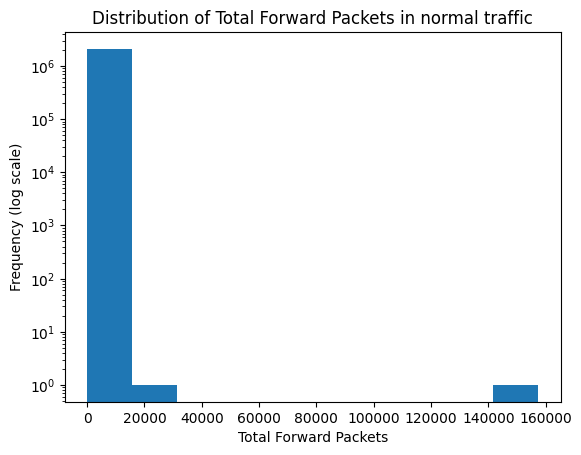

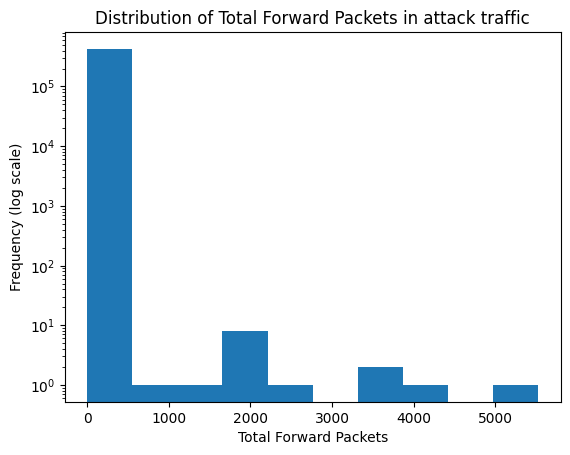


- the rate of the unusually small total_backward_packets of the normal flow is 0.00% 
the rate of the unusually small total_backward_packets of the attack flow is 0.00%,
so both doesn't have unusually small total_backward_packets
- the rate of the unusually large total_backward_packets of the normal flow is 14.27% 
the rate of the unusually large total_backward_packets of the attack flow is 1.66%,
so the normal flow are more associated with unusually large total_backward_packets than the attack flow



In [41]:
normals = cicids[cicids['binary_cat'] == 0]['total_backward_packets']
normals_des = normals.describe()
Q1_normal = normals_des['25%']
Q3_normal = normals_des['75%']
IQR_normal = Q3_normal - Q1_normal
small_outliers_limit_normal = Q1_normal - 1.5 * IQR_normal
small_outliers_count_normal = (normals < small_outliers_limit_normal).sum()
small_outliers_rate_normal = small_outliers_count_normal / len(normals) * 100
large_outliers_limit_normal = Q3_normal + 1.5 * IQR_normal
large_outliers_count_normal = (normals > large_outliers_limit_normal).sum()
large_outliers_rate_normal = large_outliers_count_normal / len(normals) * 100

attacks = cicids[cicids['binary_cat'] == 1]['total_backward_packets']
attacks_des = attacks.describe()
Q1_attack = attacks_des['25%']
Q3_attack = attacks_des['75%']
IQR_attack = Q3_attack - Q1_attack
small_outliers_limit_attack = Q1_attack - 1.5 * IQR_attack
small_outliers_count_attack = (attacks < small_outliers_limit_attack).sum()
small_outliers_rate_attack = small_outliers_count_attack / len(attacks) * 100
large_outliers_limit_attack = Q3_attack + 1.5 * IQR_attack
large_outliers_count_attack = (attacks > large_outliers_limit_attack).sum()
large_outliers_rate_attack = large_outliers_count_attack / len(attacks) * 100


for i in ['normal', 'attack']:
    flow = normals if i == 'normal' else attacks
    plt.hist(flow)
    plt.yscale('log')
    plt.xlabel('Total Forward Packets')
    plt.ylabel('Frequency (log scale)')
    plt.title(f'Distribution of Total Forward Packets in {i} traffic')
    plt.show()

print(f"""
- the rate of the unusually small total_backward_packets of the normal flow is {small_outliers_rate_normal:0.2f}% 
the rate of the unusually small total_backward_packets of the attack flow is {small_outliers_rate_attack:0.2f}%,
so both doesn't have unusually small total_backward_packets
- the rate of the unusually large total_backward_packets of the normal flow is {large_outliers_rate_normal:0.2f}% 
the rate of the unusually large total_backward_packets of the attack flow is {large_outliers_rate_attack:0.2f}%,
so the normal flow are more associated with unusually large total_backward_packets than the attack flow
""")

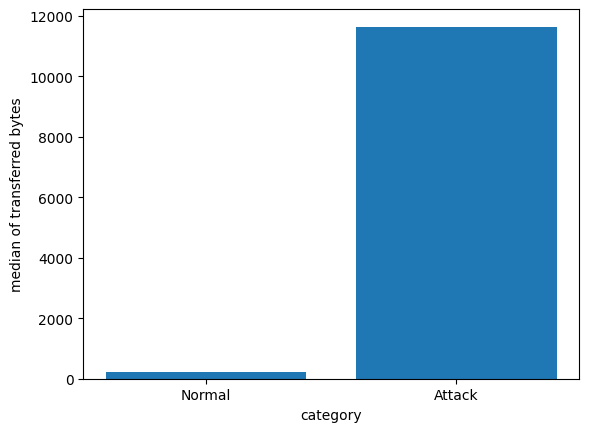


the attack flows transfer more bytes than normal flow
- normal flow: 232.0
- attack flow: 11633.0



In [42]:
normals = cicids[cicids['binary_cat'] == 0]
normals = normals['total_length_of_fwd_packets'] + normals['total_length_of_bwd_packets']

attacks = cicids[cicids['binary_cat'] == 1] 
attacks = attacks['total_length_of_fwd_packets'] + attacks['total_length_of_bwd_packets']

normal_bytes = normals.describe()
attacks_bytes = attacks.describe()

plt.bar(['Normal', 'Attack'], [normal_bytes['50%'], attacks_bytes['50%']])
plt.xlabel('category')
plt.ylabel('median of transferred bytes')
plt.show()

print(f"""
the attack flows transfer more bytes than normal flow
- normal flow: {normal_bytes['50%']}
- attack flow: {attacks_bytes['50%']}
""")

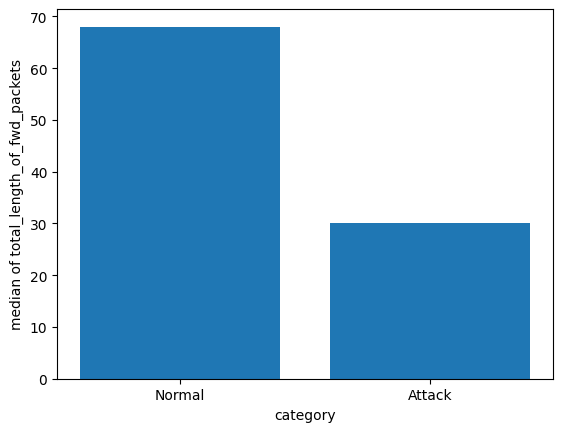


Benign flows generally have higher total_length_of_fwd_packets than attack flows.
- normal flow: 68.0
- attack flow: 30.0



In [43]:
normals = cicids[cicids['binary_cat'] == 0]['total_length_of_fwd_packets']
attacks = cicids[cicids['binary_cat'] == 1] ['total_length_of_fwd_packets']
normal_des = normals.describe()
attacks_des = attacks.describe()

# print(normal_des)
# print(attacks_des)

plt.bar(['Normal', 'Attack'], [normal_des['50%'], attacks_des['50%']])
plt.xlabel('category')
plt.ylabel('median of total_length_of_fwd_packets')
plt.show()

print(f"""
Benign flows generally have higher total_length_of_fwd_packets than attack flows.
- normal flow: {normal_des['50%']}
- attack flow: {attacks_des['50%']}
""")
# mean: normal > attack
# median: normal > attack
# max: normal > attack
# min: normal = attack = 0
# std: normal > attack
# 75%: normal < attack

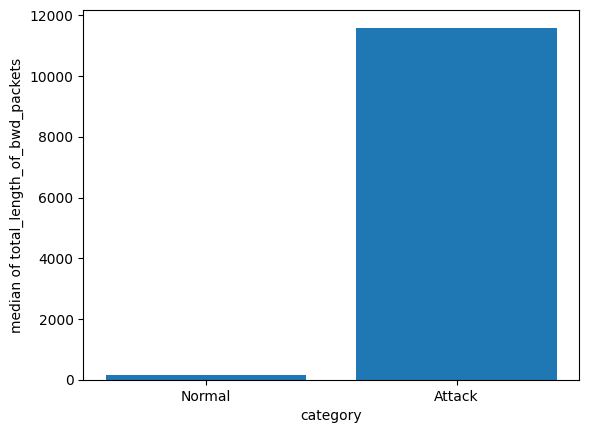


Attack flows generally have higher total_length_of_bwd_packets than normal flows.
- normal flow: 144.0
- attack flow: 11595.0



In [44]:
normals = cicids[cicids['binary_cat'] == 0]['total_length_of_bwd_packets']
attacks = cicids[cicids['binary_cat'] == 1] ['total_length_of_bwd_packets']
normal_des = normals.describe()
attacks_des = attacks.describe()

# print(normal_des)
# print(attacks_des)

plt.bar(['Normal', 'Attack'], [normal_des['50%'], attacks_des['50%']])
plt.xlabel('category')
plt.ylabel('median of total_length_of_bwd_packets')
plt.show()

print(f"""
Attack flows generally have higher total_length_of_bwd_packets than normal flows.
- normal flow: {normal_des['50%']}
- attack flow: {attacks_des['50%']}
""")
# mean: normal < attack
# median: normal < attack
# max: normal < attack
# min: normal = attack = 0
# std: normal > attack
# 75%: normal < attack

## Ports and network endpoints
- Which destination port is most common for benign traffic?
- Which destination port is most common for attack traffic?
- Are some destination ports strongly associated with attacks?
- Does destination_port have a different distribution between benign and attack traffic?

In [45]:
normal = cicids[cicids['binary_cat'] == 0]['destination_port'].value_counts()
most_port = (normal.idxmax(), normal.max())
print(f"the most common destination port is {most_port[0]} with {most_port[1]}")

the most common destination port is 53 with 876772


In [51]:
attacks = cicids[cicids['binary_cat'] == 1]['destination_port'].value_counts()
most_port = (attacks.idxmax(), attacks.max())
print(f"the most common destination port is {most_port[0]} with {most_port[1]}")

the most common destination port is 80 with 324092


In [62]:
normal = cicids[cicids['binary_cat'] == 0]['destination_port'].value_counts()
port_sum_normal = normal.sum()
port_rates_normal = normal.map(lambda x : (x/port_sum * 100).round(2))
most_port_rates_normal = port_rates_normal[port_rates_normal>0]
most_port_rates_normal

destination_port
53       41.88
443      22.38
80       10.39
123       1.02
22        0.33
389       0.28
88        0.24
21        0.16
137       0.14
465       0.13
3268      0.11
139       0.11
445       0.09
0         0.07
8080      0.06
135       0.05
138       0.04
49666     0.04
5353      0.02
5355      0.02
49671     0.02
1900      0.01
1042      0.01
1041      0.01
1037      0.01
1026      0.01
3478      0.01
51296     0.01
1         0.01
Name: count, dtype: float64

In [63]:
attacks = cicids[cicids['binary_cat'] == 1]['destination_port'].value_counts()
port_sum_attacks = attacks.sum()
port_rates_attacks = attacks.map(lambda x : (x/port_sum * 100).round(2))
most_port_rates_attacks = port_rates_attacks[port_rates_attacks>0]
most_port_rates_attacks

destination_port
80      15.48
21       0.29
22       0.17
8080     0.06
139      0.01
445      0.01
444      0.01
443      0.01
199      0.01
110      0.01
3306     0.01
256      0.01
111      0.01
1025     0.01
135      0.01
143      0.01
993      0.01
8888     0.01
5900     0.01
995      0.01
3389     0.01
Name: count, dtype: float64

In [64]:
print("""
most attacks use the destination port 80 by ~= 15% unlike the normal flows that often use use 53 (42%), 443 (22%) and 80 (10%). But we 
cannot say that the 80 is more associated to attacks
""")


most attacks use the destination port 80 by ~= 15% unlike the normal flows that use 53 (42%), 443 (22%) and 80 (10%)



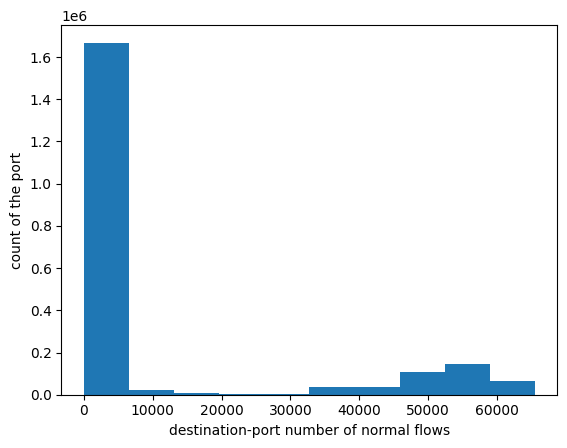

In [73]:
normal = cicids[cicids['binary_cat'] == 0]['destination_port']
plt.hist(normal)
plt.xlabel('destination-port number of normal flows')
plt.ylabel('count of the port')
plt.show()

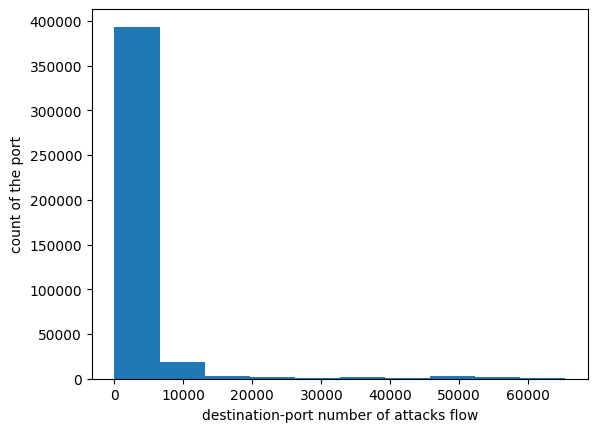

In [74]:
attacks = cicids[cicids['binary_cat'] == 1]['destination_port']
plt.hist(attacks)
plt.xlabel('destination-port number of attacks flow')
plt.ylabel('count of the port')
plt.show()

In [75]:
print("both distribution are skew to right")

both distribution are skew to right


## Packet behavior
- Compare these between benign and attack traffic then "Which features show the largest difference?":
    - total_fwd_packets
    - total_backward_packets
    - total_length_of_fwd_packets
    - total_length_of_bwd_packets
- Calculate the ratio: forward packets / backward packets
    - Does this ratio differ between benign and attack traffic?
Calculate: forward bytes / backward bytes
    - Does this help distinguish attacks from benign traffic?

In [116]:
fwd_bwd_packets_bytes = cicids.groupby('binary_cat')[['total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets']].median()
fwd_bwd_packets_bytes

,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets
binary_cat,,,,
0,2.0,2.0,68.0,144.0
1,4.0,5.0,30.0,11595.0


In [93]:
print("""
Based on the median values, total_length_of_bwd_packets shows by far the largest difference 
between benign and attack traffic. Its median is 11,595 bytes for attacks compared with only 
144 bytes for benign traffic. The other features show considerably smaller differences.
""")


Based on the median values, total_length_of_bwd_packets shows by far the largest difference 
between benign and attack traffic. Its median is 11,595 bytes for attacks compared with only 
144 bytes for benign traffic. The other features show considerably smaller differences.



In [117]:
fwd_bwd_packets_ratio = fwd_bwd_packets_bytes['total_fwd_packets']/fwd_bwd_packets_bytes['total_backward_packets']
fwd_bwd_packets_ratio

binary_cat
0    1.0
1    0.8
dtype: float64

In [118]:
fwd_bwd_bytes_ratio = fwd_bwd_packets_bytes['total_length_of_fwd_packets']/fwd_bwd_packets_bytes['total_length_of_bwd_packets']
fwd_bwd_bytes_ratio

binary_cat
0    0.472222
1    0.002587
dtype: float64

In [ ]:
print("""
the ratio of forward_packets/backward_packets generally is 1 for normal flows meaning the same number of packets is in both forward and backward unlike
the ratio of forward_packets/backward_packet for attacks traffic that is 0.8 meaning generally the number of backward packets is more than forward packets
But for bytes ratio varies
- for normal traffic 0.5 meaning the backward bytes is more than forward bytes
- for attacks traffic 0.003 meaning the backward bytes is much more than forward bytes
Backward traffic is generally greater than forward traffic in both packet count and bytes for 
attack flows, while the byte imbalance is particularly pronounced.
""")

## Timing behavior
- Compare flow_duration between the different major_cat categories.
- Which attack category has the longest average flow duration?
- Which attack category has the shortest average flow duration?
- Do DoS attacks have a noticeably different flow_duration distribution from benign traffic?
- Do DDoS attacks behave differently from DoS attacks in terms of packet counts and flow duration?

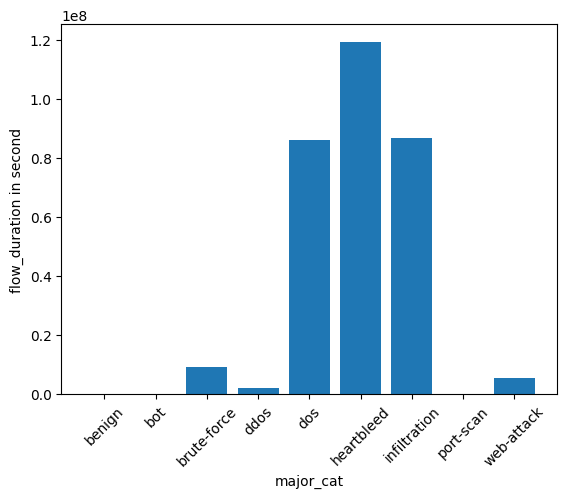

major_cat
benign              38999.5
bot                 70987.0
brute-force       9114177.0
ddos              1879024.0
dos              85872099.0
heartbleed      119261118.0
infiltration     86726608.0
port-scan              50.0
web-attack        5487328.0
Name: flow_duration, dtype: float64

In [168]:
major_cat = cicids.groupby('major_cat')
flow_duration_major_cat_median = major_cat['flow_duration'].median()
plt.bar(flow_duration_major_cat_median.index, flow_duration_major_cat_median.values)
plt.xticks(rotation = 45)
plt.xlabel('major_cat')
plt.ylabel('flow_duration in second')
plt.show()
flow_duration_major_cat_median

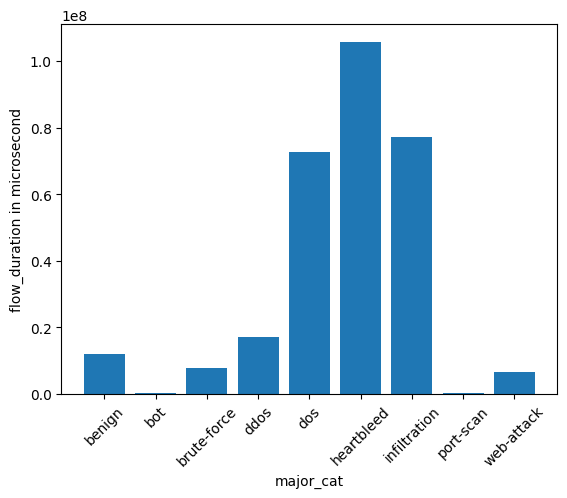

major_cat
benign          1.209757e+07
bot             3.532787e+05
brute-force     7.889303e+06
ddos            1.695255e+07
dos             7.262893e+07
heartbleed      1.057661e+08
infiltration    7.722009e+07
port-scan       1.448968e+05
web-attack      6.646526e+06
Name: flow_duration, dtype: float64

In [170]:
flow_duration_major_cat_mean =  major_cat['flow_duration'].mean()
plt.bar(flow_duration_major_cat_mean.index, flow_duration_major_cat_mean.values)
plt.xticks(rotation = 45)
plt.xlabel('major_cat')
plt.ylabel('flow_duration in microsecond')
plt.show()
flow_duration_major_cat_mean

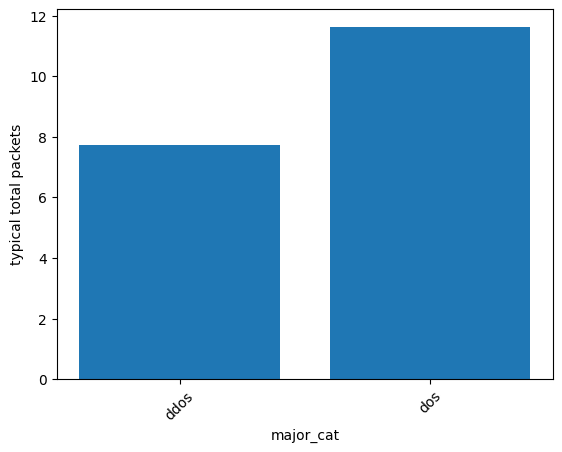

major_cat
ddos     7.728220
dos     11.623131
dtype: float64

In [166]:
packet_counts_major_cat_mean = major_cat[['total_fwd_packets', 'total_backward_packets']].mean()
packet_counts_ddosVsdos = packet_counts_major_cat_mean.loc[['ddos', 'dos'], :]
total_packet_counts_ddosVsdos = packet_counts_ddosVsdos['total_fwd_packets'] + packet_counts_ddosVsdos['total_backward_packets']
plt.bar(total_packet_counts_ddosVsdos.index, total_packet_counts_ddosVsdos.values)
plt.xticks(rotation = 45)
plt.xlabel('major_cat')
plt.ylabel('typical total packets')
plt.show()
total_packet_counts_ddosVsdos

In [167]:
print(f"""
- the attack category that has the longest average flow duration: {flow_duration_major_cat_mean.idxmax()} with {flow_duration_major_cat_mean.max().round(2)}
- the attack category that has the shortest average flow duration:  {flow_duration_major_cat_mean.idxmin()} with {flow_duration_major_cat_mean.min().round(2)}
- Do DoS attacks have a noticeably different flow_duration distribution from benign traffic?
Yes, the difference between them {(flow_duration_major_cat_mean['dos'] - flow_duration_major_cat_mean['benign']).round()}
- Do DDoS attacks behave differently from DoS attacks in terms of packet counts and flow duration?
Yes, the difference between them {(flow_duration_major_cat_mean['dos'] - flow_duration_major_cat_mean['ddos']).round()}
- Do DDoS attacks behave differently from DoS attacks in terms of packet counts
Yes, the difference between them {(total_packet_counts_ddosVsdos['dos'] - total_packet_counts_ddosVsdos['ddos']).round()}
""")


- the attack category that has the longest average flow duration: heartbleed with 105766088.86
- the attack category that has the shortest average flow duration:  port-scan with 144896.75
- Do DoS attacks have a noticeably different flow_duration distribution from benign traffic?
Yes, the difference between them 60531364.0
- Do DDoS attacks behave differently from DoS attacks in terms of packet counts and flow duration?
Yes, the difference between them 55676377.0
- Do DDoS attacks behave differently from DoS attacks in terms of packet counts
Yes, the difference between them 4.0



## Feature relationships
- Which numerical features are most strongly correlated with binary_cat?
- Which numerical features are highly correlated with each other?
- Are there pairs of features with correlation close to 1 or -1?
- Do you think any highly correlated features could be redundant before modeling?

In [294]:
numerical_features_binary_cat_corr = cicids[numerical_features + ['binary_cat']].corr()
numerical_features_binary_cat_corr = numerical_features_binary_cat_corr['binary_cat']
numerical_features_binary_cat_corr.drop('binary_cat', inplace=True)
numerical_features_binary_cat_corr

destination_port              -0.159855
flow_duration                  0.279850
total_fwd_packets             -0.007698
total_backward_packets        -0.008410
total_length_of_fwd_packets   -0.015566
total_length_of_bwd_packets    0.001290
fwd_packet_length_max         -0.048787
fwd_packet_length_min         -0.131202
fwd_packet_length_mean        -0.074386
fwd_packet_length_std         -0.026091
bwd_packet_length_max          0.597541
bwd_packet_length_min         -0.265318
bwd_packet_length_mean         0.595878
bwd_packet_length_std          0.611825
flow_bytes/s                  -0.022155
flow_packets/s                -0.068984
flow_iat_mean                  0.224420
flow_iat_std                   0.410747
flow_iat_max                   0.471675
flow_iat_min                   0.018002
fwd_iat_total                  0.280896
fwd_iat_mean                   0.192799
fwd_iat_std                    0.505942
fwd_iat_max                    0.470935
fwd_iat_min                   -0.021393


In [295]:
numerical_features_binary_cat_corr_largest = numerical_features_binary_cat_corr.nlargest(5)
numerical_features_binary_cat_corr_largest

bwd_packet_length_std     0.611825
bwd_packet_length_max     0.597541
bwd_packet_length_mean    0.595878
avg_bwd_segment_size      0.595878
packet_length_std         0.573979
Name: binary_cat, dtype: float64

In [296]:
numerical_features_binary_cat_corr_smallest = numerical_features_binary_cat_corr.nsmallest(5)
numerical_features_binary_cat_corr_smallest

min_packet_length         -0.277202
bwd_packet_length_min     -0.265318
destination_port          -0.159855
fwd_packet_length_min     -0.131202
init_win_bytes_backward   -0.093118
Name: binary_cat, dtype: float64

In [297]:
numerical_features_corr = cicids[numerical_features].corr()
numerical_features_corr

,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,act_data_pkt_fwd,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min
destination_port,1.000000,-0.171517,-0.023590,-0.019722,0.011667,-0.009951,0.091365,-0.047238,0.136946,0.123183,...,-0.015239,0.000614,-0.041084,-0.048395,-0.058343,-0.027421,-0.127848,0.006799,-0.123530,-0.129410
flow_duration,-0.171517,1.000000,0.076954,0.061305,0.063473,0.030034,0.263227,-0.115555,0.134469,0.225287,...,0.043424,-0.063880,0.187518,0.239614,0.291712,0.118817,0.764821,0.240677,0.776464,0.734798
total_fwd_packets,-0.023590,0.076954,1.000000,0.991594,0.162656,0.980785,0.039957,-0.016563,0.012555,0.022074,...,0.967304,-0.010101,0.070012,0.078094,0.094336,0.044524,0.024740,0.011486,0.025909,0.022764
total_backward_packets,-0.019722,0.061305,0.991594,1.000000,0.111188,0.989786,0.034531,-0.011771,0.008645,0.017528,...,0.968429,-0.005563,0.054800,0.055477,0.070050,0.040023,0.019970,0.007875,0.020537,0.018615
total_length_of_fwd_packets,0.011667,0.063473,0.162656,0.111188,1.000000,0.054473,0.211347,-0.001118,0.202437,0.173694,...,0.163786,-0.012233,0.098788,0.111714,0.130109,0.061551,0.022812,0.029050,0.026566,0.018431
total_length_of_bwd_packets,-0.009951,0.030034,0.980785,0.989786,0.054473,1.000000,0.012801,-0.006868,-0.001446,0.003570,...,0.972735,-0.003852,0.028529,0.026954,0.035366,0.021909,0.013983,0.004252,0.014159,0.013358
fwd_packet_length_max,0.091365,0.263227,0.039957,0.034531,0.211347,0.012801,1.000000,-0.004052,0.889403,0.968978,...,0.027405,-0.048165,0.122130,0.088367,0.139444,0.104489,0.171814,0.175744,0.190379,0.147662
fwd_packet_length_min,-0.047238,-0.115555,-0.016563,-0.011771,-0.001118,-0.006868,-0.004052,1.000000,0.244504,-0.078415,...,-0.009072,-0.002577,-0.036865,-0.033402,-0.045929,-0.028660,-0.078456,-0.032441,-0.080760,-0.074207
fwd_packet_length_mean,0.136946,0.134469,0.012555,0.008645,0.202437,-0.001446,0.889403,0.244504,1.000000,0.897512,...,0.012579,-0.057161,0.093334,0.054752,0.092197,0.081901,0.120160,0.177218,0.140850,0.096257
fwd_packet_length_std,0.123183,0.225287,0.022074,0.017528,0.173694,0.003570,0.968978,-0.078415,0.897512,1.000000,...,0.016039,-0.053083,0.105978,0.065972,0.113216,0.094487,0.174859,0.189086,0.195173,0.149382


In [298]:
unstacked_numerical_features_corr = numerical_features_corr.unstack()
correlated_numerical_features = [x for x in unstacked_numerical_features_corr.index if x[0] > x[1]]
clean_unstacked_numerical_features_corr = unstacked_numerical_features_corr[correlated_numerical_features]
clean_unstacked_numerical_features_corr

destination_port  bwd_packet_length_max    -0.212389
                  bwd_packet_length_min    -0.262717
                  bwd_packet_length_mean   -0.238553
                  bwd_packet_length_std    -0.190312
                  bwd_iat_total            -0.119455
                                              ...   
idle_min          active_std                0.019330
                  active_max                0.071698
                  active_min                0.111195
                  idle_mean                 0.990078
                  idle_max                  0.961249
Length: 1770, dtype: float64

### Drop some duplicated columns
From the correlation above, we can conclude that there are some columns that is totally/nearly totally correlated to each other (1 : 0.95). So, we can drop these columns to avoid duplicating. For example: total_fwd_packets & subflow_fwd_packets

In [319]:
clean_numerical_features = [x for x in clean_unstacked_numerical_features_corr.index if abs(clean_unstacked_numerical_features_corr[x]) >= 0.95]
clean_unstacked_numerical_features_corr[clean_numerical_features]

total_fwd_packets  total_backward_packets    0.991594
                   fwd_header_length         0.988318
                   bwd_header_length         0.983830
                   fwd_header_length.1       0.988318
                   subflow_fwd_packets       1.000000
                                               ...   
idle_max           flow_iat_max              0.989508
                   fwd_iat_max               0.988679
idle_min           flow_iat_max              0.951250
                   idle_mean                 0.990078
                   idle_max                  0.961249
Length: 62, dtype: float64

In [320]:
columns_to_drop = list(set(x[1] for x in clean_numerical_features))

['avg_fwd_segment_size',
 'subflow_bwd_bytes',
 'flow_iat_max',
 'subflow_fwd_packets',
 'fwd_iat_max',
 'bwd_packet_length_max',
 'subflow_bwd_packets',
 'fwd_header_length.1',
 'avg_bwd_segment_size',
 'act_data_pkt_fwd',
 'average_packet_size',
 'fwd_packet_length_max',
 'fwd_header_length',
 'flow_packets/s',
 'idle_max',
 'idle_mean',
 'max_packet_length',
 'total_fwd_packets',
 'flow_duration',
 'bwd_header_length',
 'total_backward_packets',
 'subflow_fwd_bytes']

In [331]:
cicids[numerical_features].columns

Index(['destination_port', 'flow_duration', 'total_fwd_packets',
       'total_backward_packets', 'total_length_of_fwd_packets',
       'total_length_of_bwd_packets', 'fwd_packet_length_max',
       'fwd_packet_length_min', 'fwd_packet_length_mean',
       'fwd_packet_length_std', 'bwd_packet_length_max',
       'bwd_packet_length_min', 'bwd_packet_length_mean',
       'bwd_packet_length_std', 'flow_bytes/s', 'flow_packets/s',
       'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min',
       'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max',
       'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std',
       'bwd_iat_max', 'bwd_iat_min', 'fwd_header_length', 'bwd_header_length',
       'fwd_packets/s', 'bwd_packets/s', 'min_packet_length',
       'max_packet_length', 'packet_length_mean', 'packet_length_std',
       'packet_length_variance', 'down/up_ratio', 'average_packet_size',
       'avg_fwd_segment_size', 'avg_bwd_segment_size', 'fwd_header_lengt

In [332]:
numerical_features = [feature for feature in numerical_features if feature not in columns_to_drop]

In [333]:
cicids[numerical_features].columns

Index(['destination_port', 'total_length_of_fwd_packets',
       'total_length_of_bwd_packets', 'fwd_packet_length_min',
       'fwd_packet_length_mean', 'fwd_packet_length_std',
       'bwd_packet_length_min', 'bwd_packet_length_mean',
       'bwd_packet_length_std', 'flow_bytes/s', 'flow_iat_mean',
       'flow_iat_std', 'flow_iat_min', 'fwd_iat_total', 'fwd_iat_mean',
       'fwd_iat_std', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean',
       'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'fwd_packets/s',
       'bwd_packets/s', 'min_packet_length', 'packet_length_mean',
       'packet_length_std', 'packet_length_variance', 'down/up_ratio',
       'init_win_bytes_forward', 'init_win_bytes_backward',
       'min_seg_size_forward', 'active_mean', 'active_std', 'active_max',
       'active_min', 'idle_std', 'idle_min'],
      dtype='str')

In [47]:
cicids.columns

Index(['destination_port', 'flow_duration', 'total_fwd_packets',
       'total_backward_packets', 'total_length_of_fwd_packets',
       'total_length_of_bwd_packets', 'fwd_packet_length_max',
       'fwd_packet_length_min', 'fwd_packet_length_mean',
       'fwd_packet_length_std', 'bwd_packet_length_max',
       'bwd_packet_length_min', 'bwd_packet_length_mean',
       'bwd_packet_length_std', 'flow_bytes/s', 'flow_packets/s',
       'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min',
       'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max',
       'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std',
       'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags',
       'fwd_urg_flags', 'bwd_urg_flags', 'fwd_header_length',
       'bwd_header_length', 'fwd_packets/s', 'bwd_packets/s',
       'min_packet_length', 'max_packet_length', 'packet_length_mean',
       'packet_length_std', 'packet_length_variance', 'fin_flag_count',
       'syn_flag_co

In [334]:
cicids = cicids.drop(columns = columns_to_drop)

In [335]:
cicids.columns

Index(['destination_port', 'total_length_of_fwd_packets',
       'total_length_of_bwd_packets', 'fwd_packet_length_min',
       'fwd_packet_length_mean', 'fwd_packet_length_std',
       'bwd_packet_length_min', 'bwd_packet_length_mean',
       'bwd_packet_length_std', 'flow_bytes/s', 'flow_iat_mean',
       'flow_iat_std', 'flow_iat_min', 'fwd_iat_total', 'fwd_iat_mean',
       'fwd_iat_std', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean',
       'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags',
       'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'fwd_packets/s',
       'bwd_packets/s', 'min_packet_length', 'packet_length_mean',
       'packet_length_std', 'packet_length_variance', 'fin_flag_count',
       'syn_flag_count', 'rst_flag_count', 'psh_flag_count', 'ack_flag_count',
       'urg_flag_count', 'cwe_flag_count', 'ece_flag_count', 'down/up_ratio',
       'init_win_bytes_forward', 'init_win_bytes_backward',
       'min_seg_size_forward', 'active_mean', 'active_st

## Attack-category analysis
For each major_cat:
- What are its top 5 most distinctive numerical features compared with benign traffic?
- Does each attack category have a different network behavior?
- Which attack categories appear easiest to distinguish based on the numerical features?
- Which attack categories appear most similar to benign traffic?

In [387]:
categories_numerical_features = cicids.groupby('major_cat')[numerical_features].median()
categories_numerical_features

,destination_port,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,bwd_packet_length_min,bwd_packet_length_mean,bwd_packet_length_std,flow_bytes/s,...,down/up_ratio,init_win_bytes_forward,init_win_bytes_backward,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_std,idle_min
major_cat,,,,,,,,,,,,,,,,,,,,,
benign,80.0,68.0,144.0,6.0,38.000000,0.000000,6.0,83.000000,0.000000,4247.699163,...,1.0,122.0,-1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0
bot,8080.0,6.0,18.0,0.0,6.000000,0.000000,6.0,6.000000,0.000000,5013.133593,...,1.0,8192.0,237.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0
brute-force,21.0,107.0,188.0,0.0,11.888889,9.899495,0.0,12.533333,14.549750,353.910455,...,1.0,29200.0,227.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0
ddos,80.0,26.0,11601.0,0.0,7.000000,5.656854,0.0,1934.500000,2189.772933,160.098709,...,0.0,256.0,229.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0
dos,80.0,354.0,11595.0,0.0,53.500000,133.421459,0.0,1932.500000,2120.732252,122.934941,...,0.0,251.0,235.0,32.0,997.0,0.0,997.0,995.0,0.0,85300000.0
heartbleed,444.0,12264.0,7879536.0,0.0,4.389406,83.211635,0.0,3768.309900,2372.066530,66172.446920,...,0.0,235.0,235.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0
infiltration,444.0,6674.0,156.0,6.0,279.857143,269.610304,6.0,6.000000,0.000000,161.413786,...,1.0,255.0,1452.0,20.0,569902.0,0.0,576446.0,558514.0,0.0,11400000.0
port-scan,3546.0,0.0,6.0,0.0,0.000000,0.000000,6.0,6.000000,0.000000,137931.034500,...,1.0,29200.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0
web-attack,80.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.0,29200.0,28960.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0


In [384]:
benign_numerical_features = categories_numerical_features.loc['benign']
categories = categories_numerical_features.index.drop('benign')
for cat in categories:
    print(cat)
    cat_numerical_features = categories_numerical_features.loc[cat]
    benign_cat_numerical_features_difference = (cat_numerical_features - benign_numerical_features)/(benign_numerical_features.abs() + 1)
    top5 = benign_cat_numerical_features_difference.abs().nlargest(5)
    print(benign_cat_numerical_features_difference[top5.index])

bot
bwd_iat_total    17355.250000
bwd_iat_max      17129.000000
fwd_iat_total    14196.600000
bwd_iat_mean      8456.125000
fwd_iat_mean      4602.133334
dtype: float64
brute-force
bwd_iat_total    2.278421e+06
fwd_iat_total    1.223494e+06
fwd_iat_std      9.638610e+05
bwd_iat_std      8.420038e+05
bwd_iat_max      6.418145e+05
dtype: float64
ddos
fwd_iat_std      932411.86010
fwd_iat_total    352968.80000
fwd_iat_mean      98099.05000
bwd_iat_std       33256.78502
bwd_iat_total     18674.25000
dtype: float64
dos
idle_min         8.530000e+07
fwd_iat_std      3.500000e+07
fwd_iat_total    1.716000e+07
fwd_iat_mean     2.819999e+06
flow_iat_std     1.181654e+05
dtype: float64
heartbleed
bwd_iat_total    2.975000e+07
fwd_iat_total    2.380000e+07
bwd_iat_max      2.488248e+05
bwd_iat_std      2.298013e+05
fwd_iat_std      2.008842e+05
dtype: float64
infiltration
bwd_iat_total    2.167500e+07
fwd_iat_total    1.590000e+07
idle_min         1.140000e+07
bwd_iat_max      8.299999e+06
bwd_ia

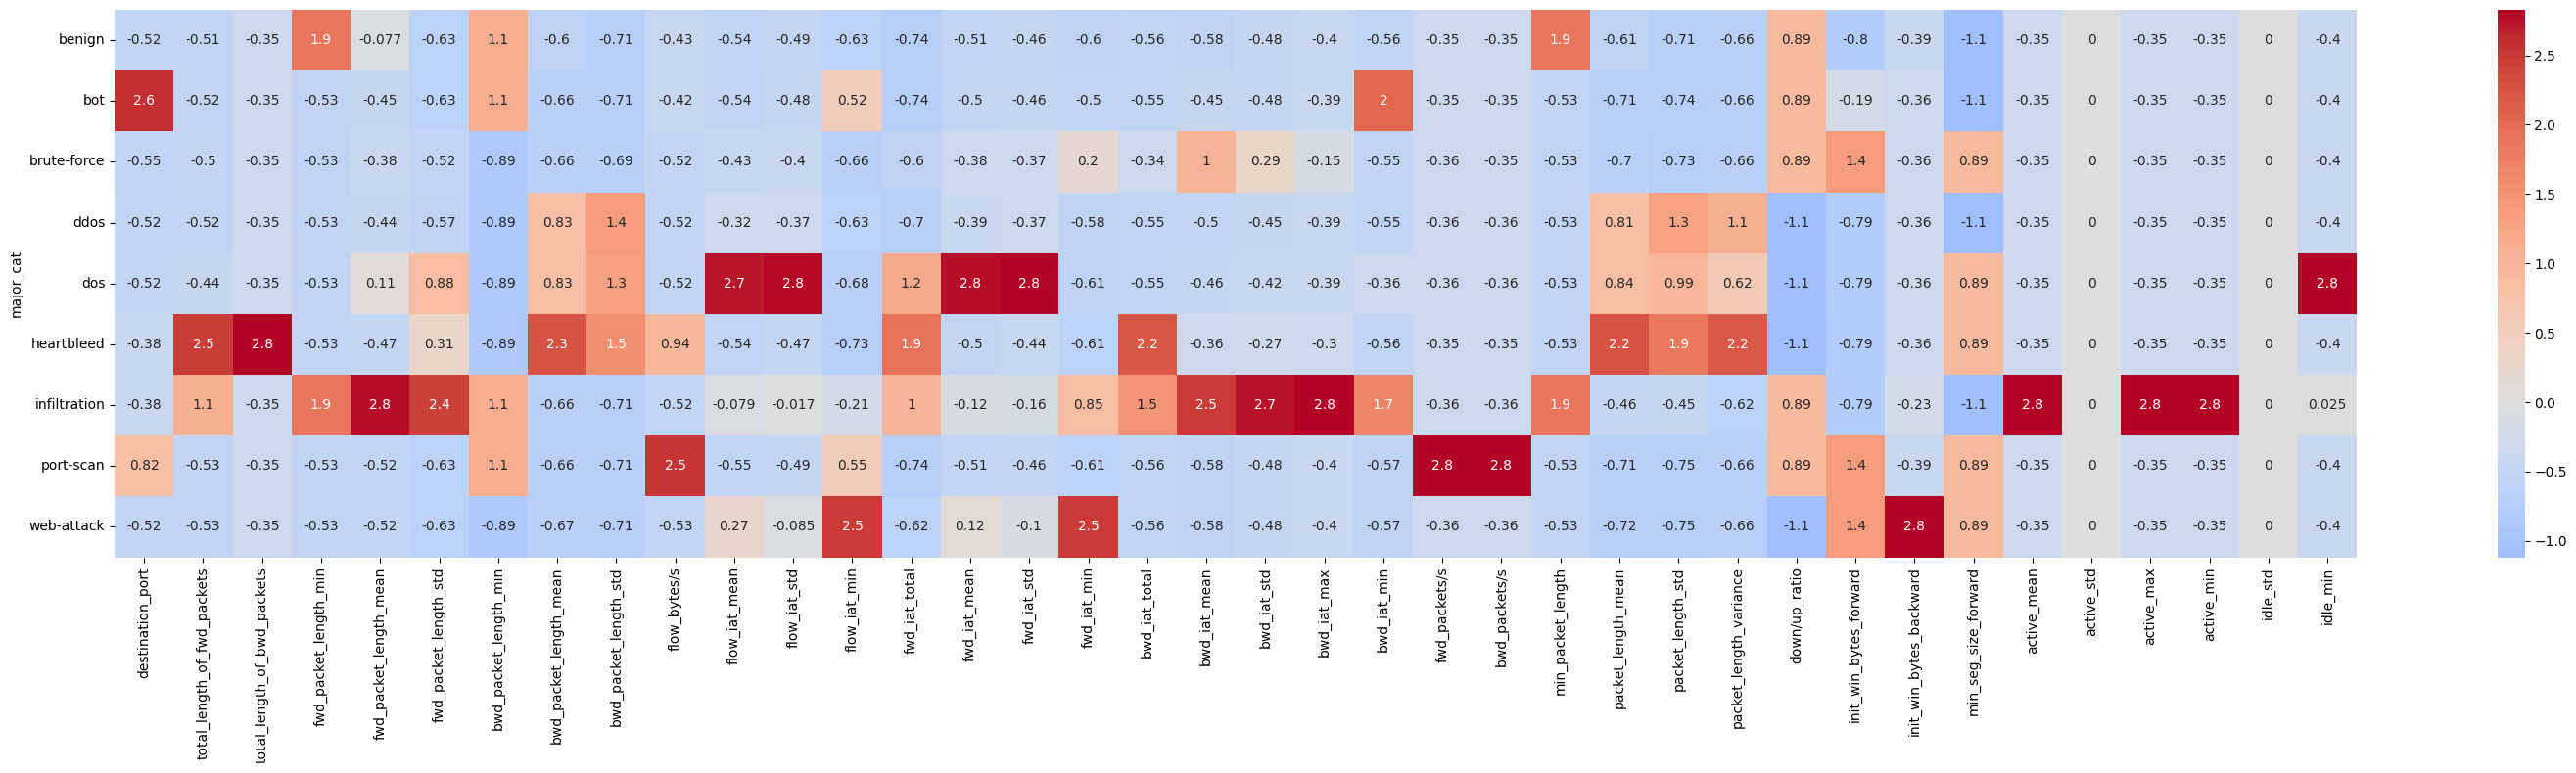

In [441]:
scaler = StandardScaler()
scaled_categories_numerical_features = scaler.fit_transform(categories_numerical_features)
scaled_categories_numerical_features = pd.DataFrame(data = scaled_categories_numerical_features, index = categories_numerical_features.index, columns=categories_numerical_features.columns)
plt.figure(figsize=(30, 8))
sns.heatmap(scaled_categories_numerical_features, cmap='coolwarm', annot=True, center=0)
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

In [442]:
print("""
from the heatmap, we can easily distinguish between
- bot
- dos
- heartbleed
- infiltration
- port-scan
- web-attack
these categories have typical high values in some numerical features

from the heatmap, these attacks are most similar to Benign
- 
""")


from the heatmap, we can easily distinguish between
- bot
- dos
- heartbleed
- infiltration
- port-scan
- web-attack
these categories have typical high values in some numerical features

from the heatmap, these attacks are most similar to Benign
- 



### Drop some unimportant columns
in the heatmap above, we can find out the features of 
active_std and idle_std are the same at all categories 
so they are useless that we cannot use them to distinguish 
between categories

In [436]:
numerical_features = [x for x in numerical_features if x not in ['active_std', 'idle_std']]
numerical_features

['destination_port',
 'total_length_of_fwd_packets',
 'total_length_of_bwd_packets',
 'fwd_packet_length_min',
 'fwd_packet_length_mean',
 'fwd_packet_length_std',
 'bwd_packet_length_min',
 'bwd_packet_length_mean',
 'bwd_packet_length_std',
 'flow_bytes/s',
 'flow_iat_mean',
 'flow_iat_std',
 'flow_iat_min',
 'fwd_iat_total',
 'fwd_iat_mean',
 'fwd_iat_std',
 'fwd_iat_min',
 'bwd_iat_total',
 'bwd_iat_mean',
 'bwd_iat_std',
 'bwd_iat_max',
 'bwd_iat_min',
 'fwd_packets/s',
 'bwd_packets/s',
 'min_packet_length',
 'packet_length_mean',
 'packet_length_std',
 'packet_length_variance',
 'down/up_ratio',
 'init_win_bytes_forward',
 'init_win_bytes_backward',
 'min_seg_size_forward',
 'active_mean',
 'active_max',
 'active_min',
 'idle_min']

In [ ]:
cicids = cicids.drop(columns = ['active_std', 'idle_std'])
cicids.columns

## Important EDA questions before ML
- Can the attack categories be distinguished using only network-flow statistics?
- Which features appear to contain the most information about whether traffic is malicious?
- Which features appear to contain the most information about the type of attack?
- Are there severe class-imbalance problems that could affect the classifier?
- Are there duplicate or highly similar records that could cause data leakage between training and testing sets?
- Are there features that should be removed because they are constant or nearly constant?
- Are there features with extreme outliers, and are those outliers meaningful network behavior or data-quality problems?
- Does the relationship between a feature and the target change depending on the attack category?

## Other analysis

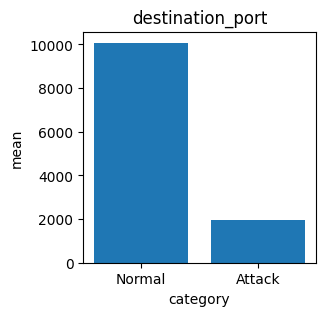

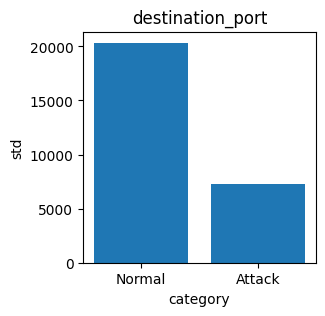

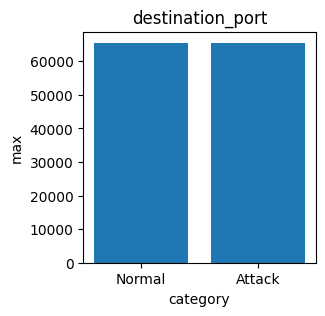

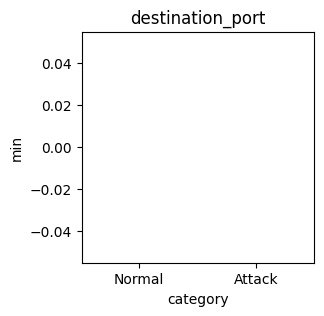

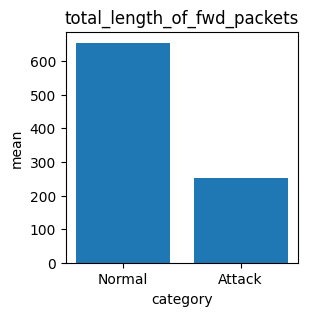

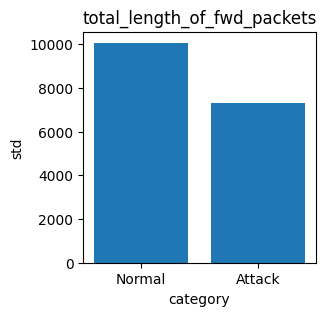

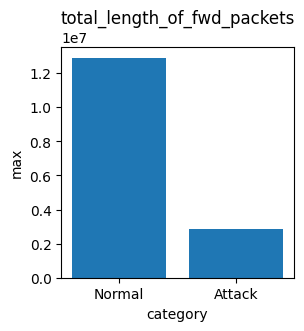

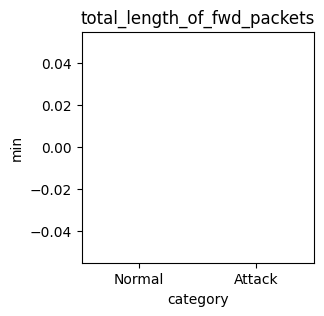

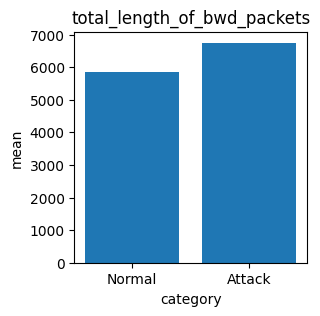

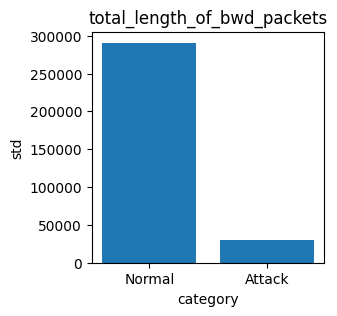

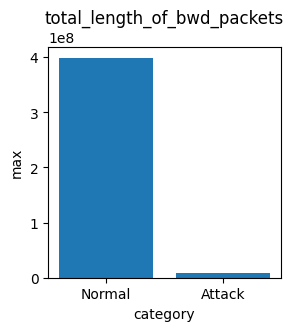

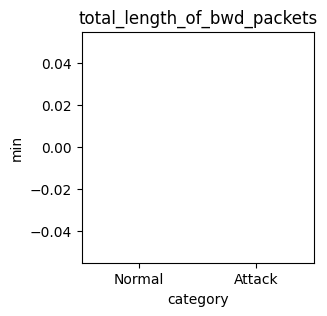

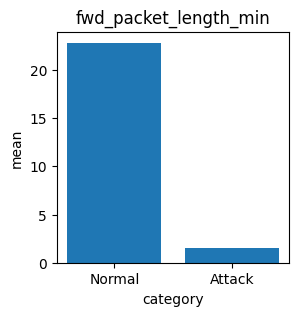

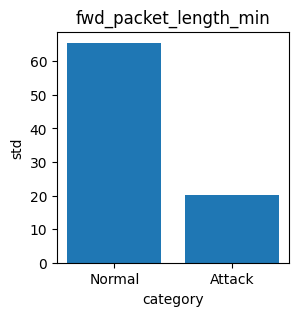

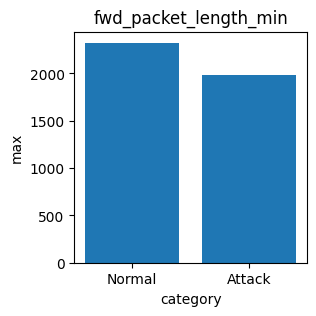

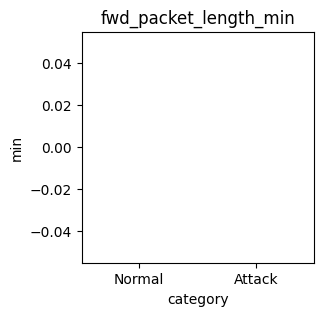

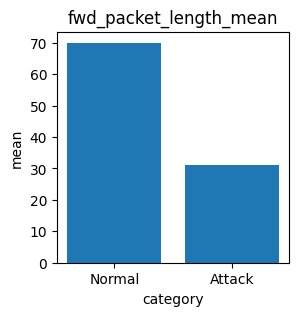

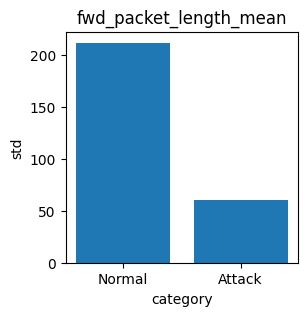

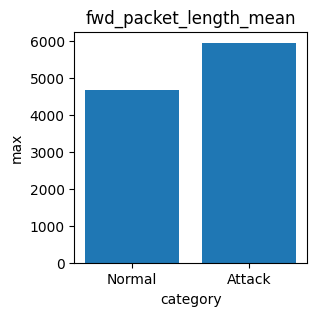

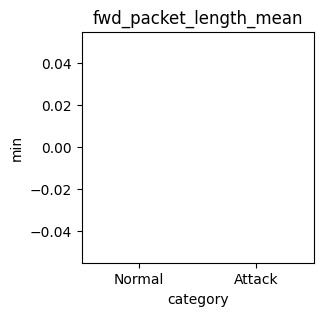

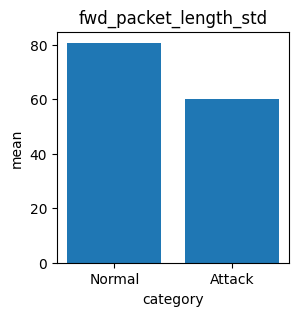

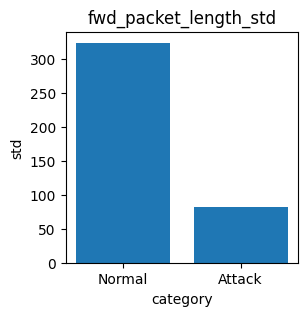

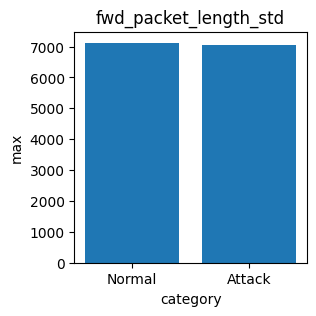

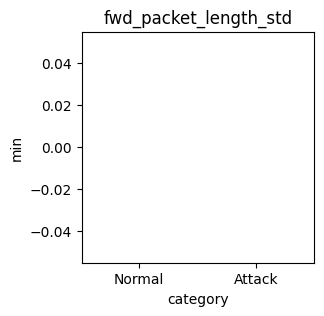

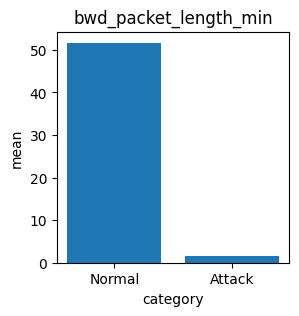

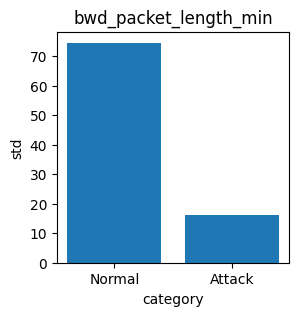

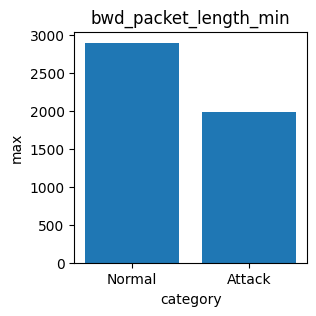

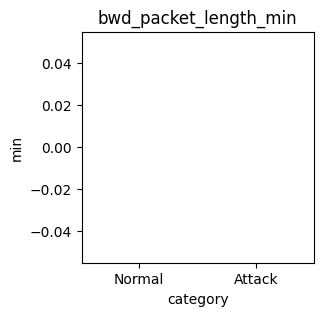

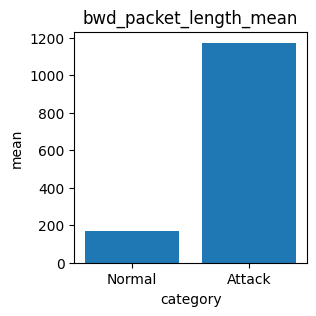

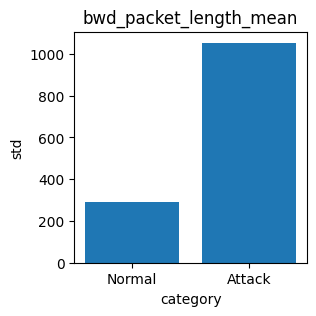

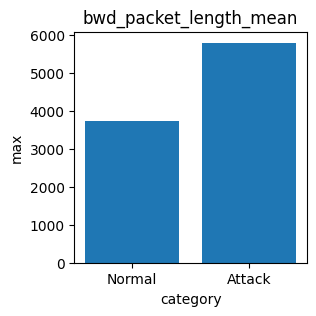

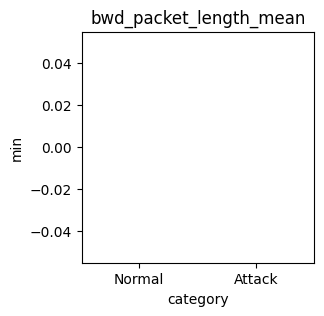

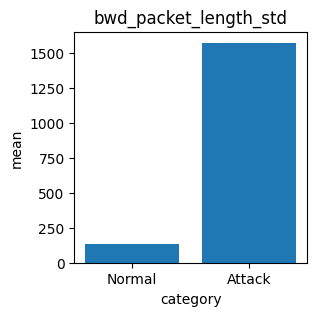

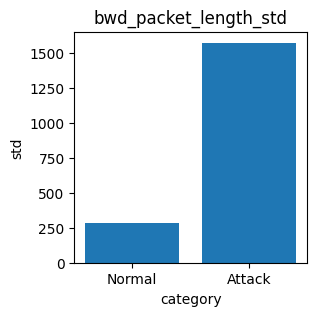

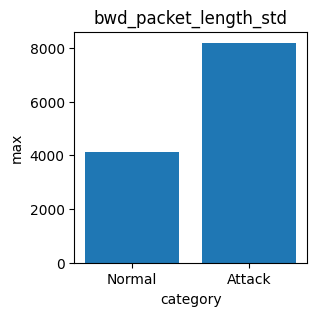

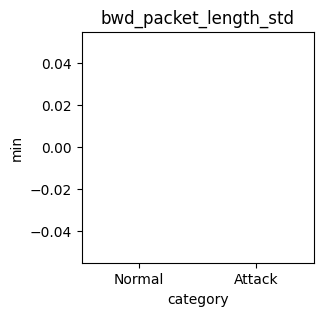

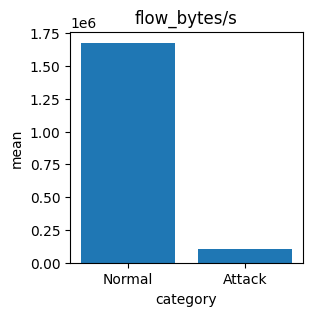

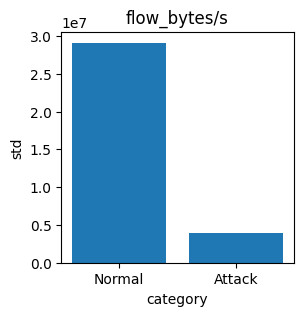

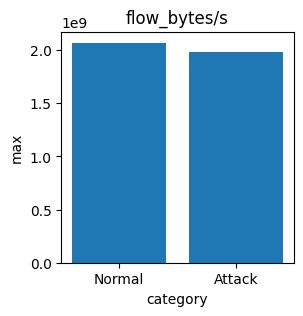

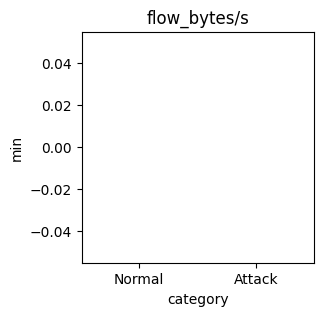

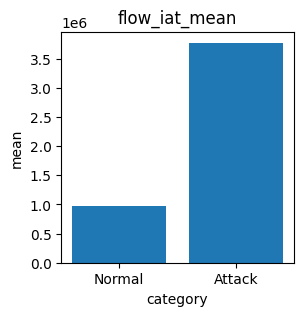

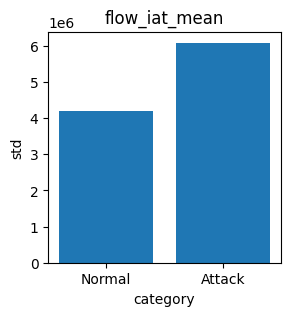

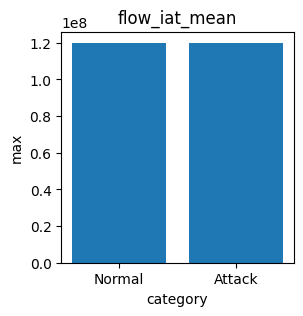

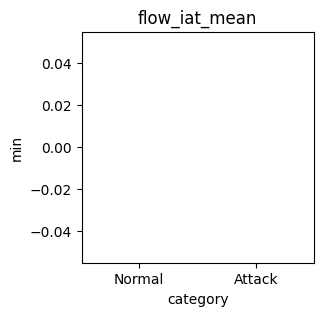

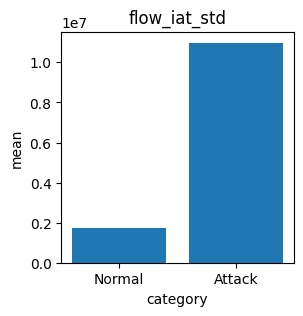

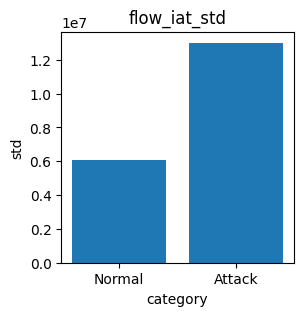

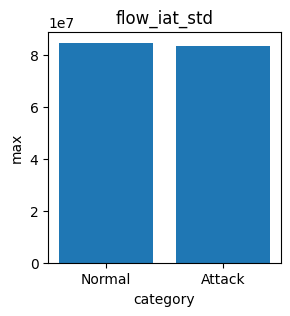

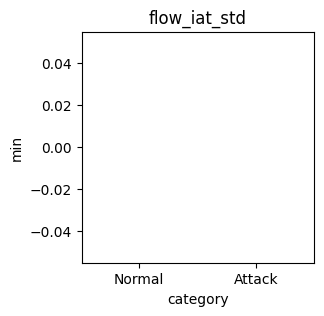

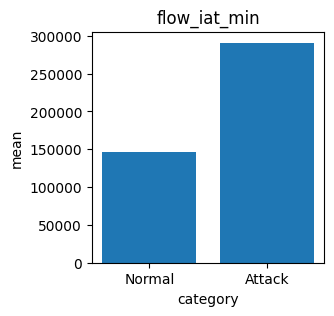

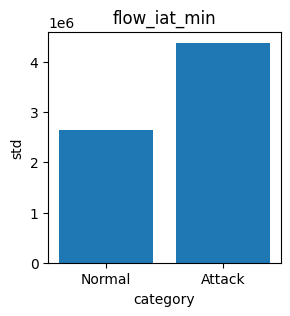

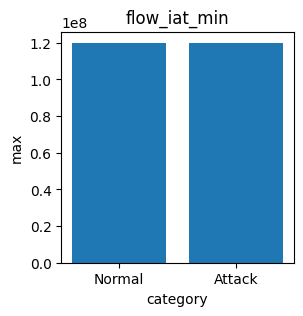

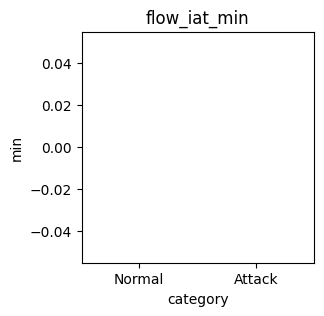

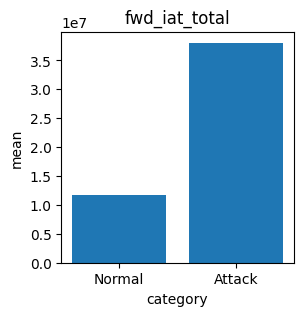

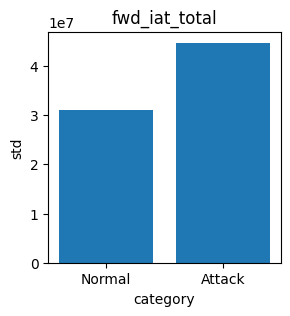

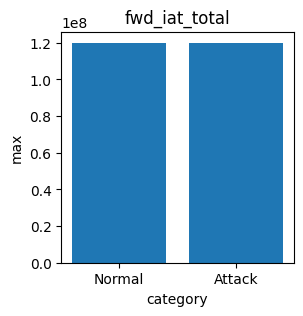

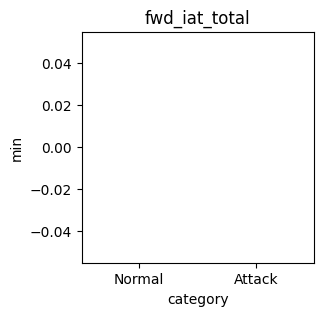

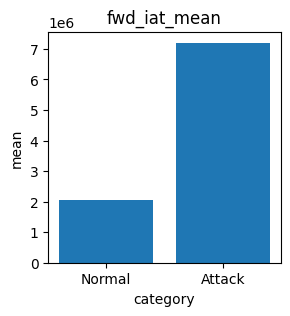

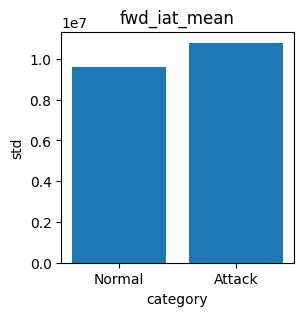

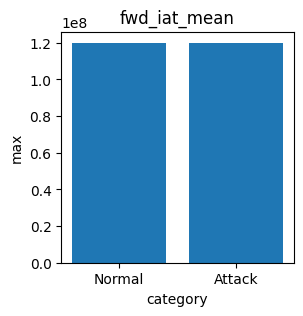

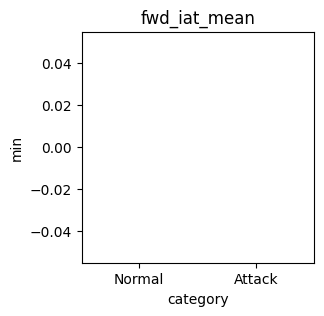

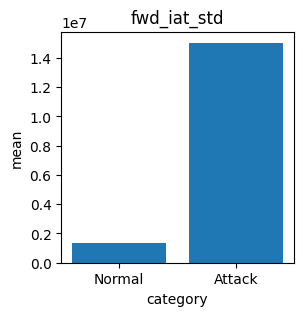

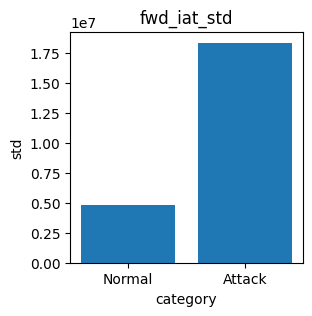

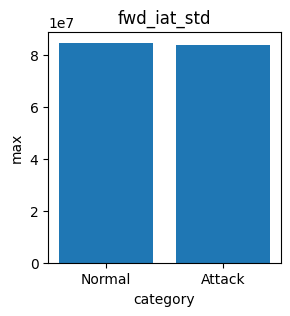

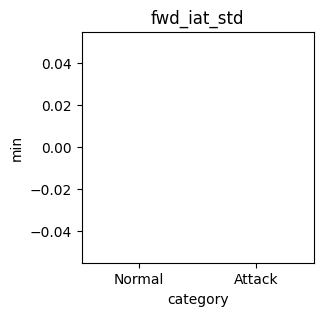

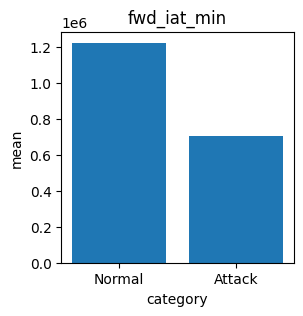

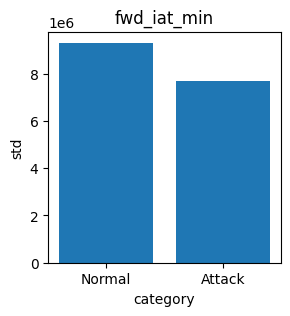

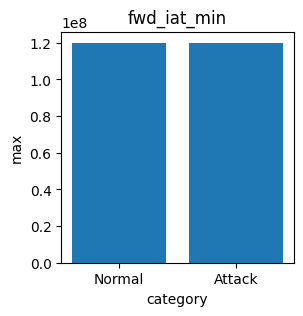

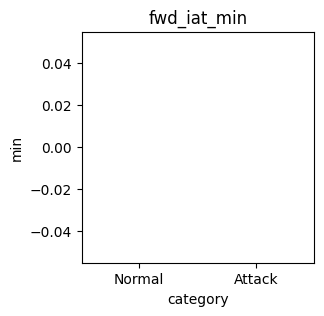

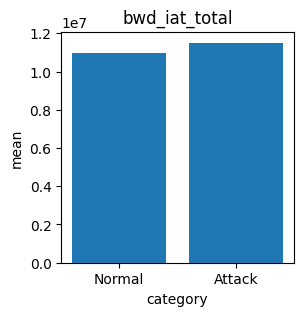

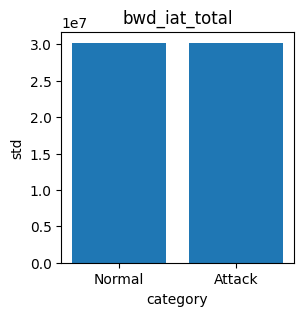

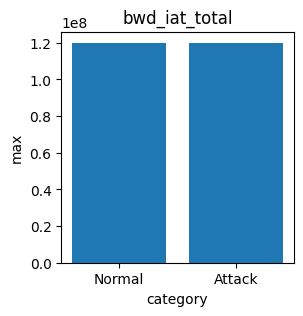

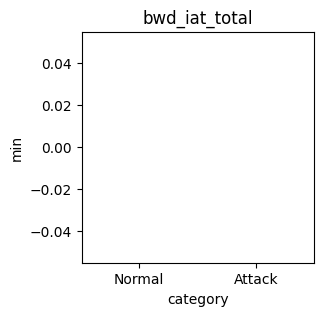

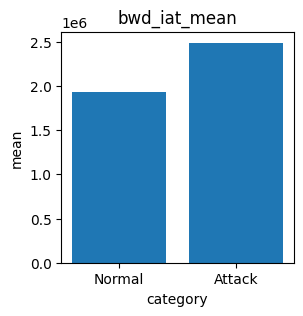

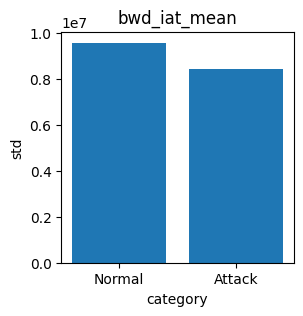

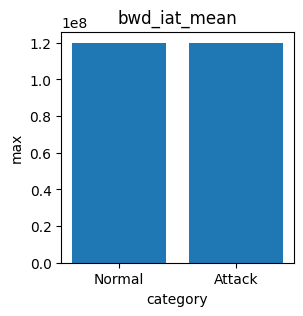

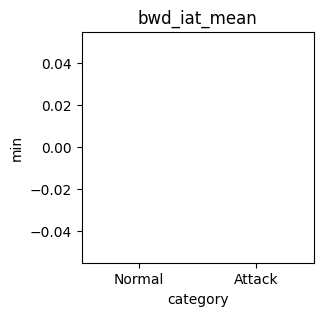

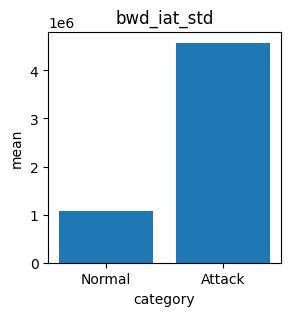

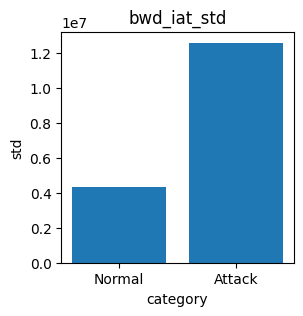

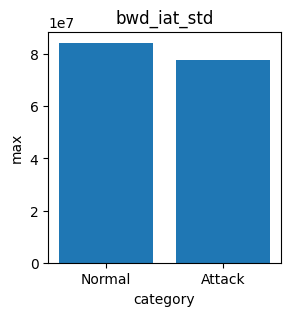

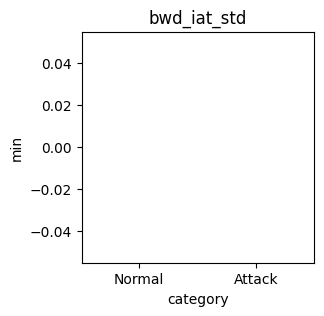

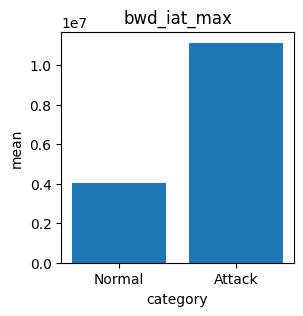

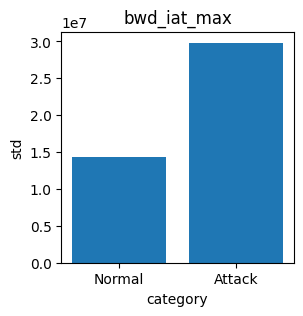

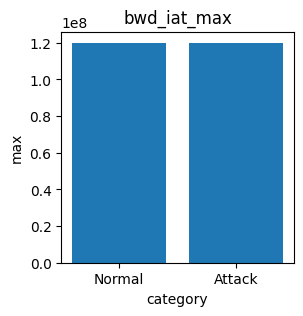

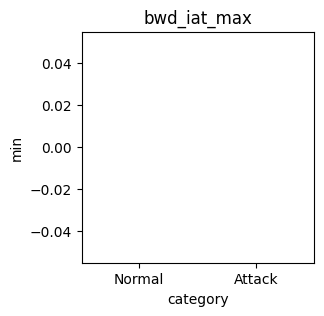

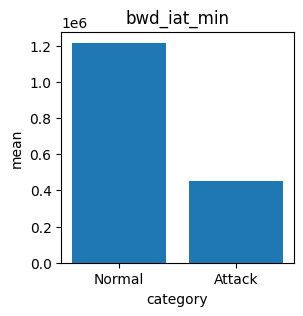

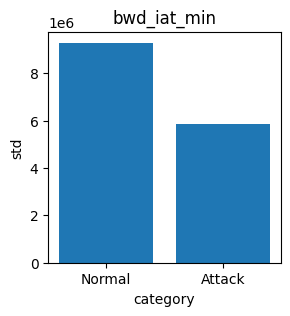

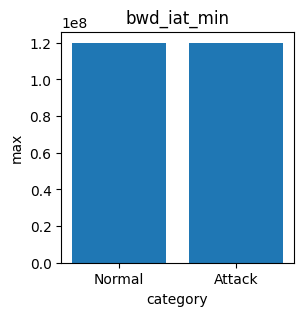

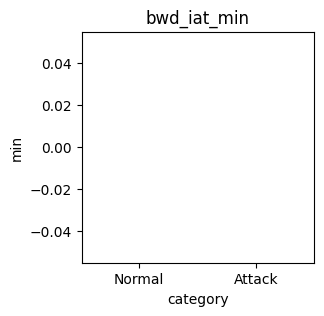

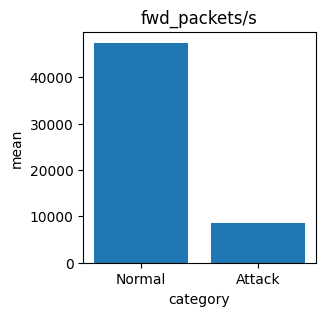

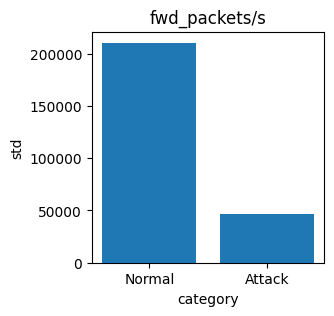

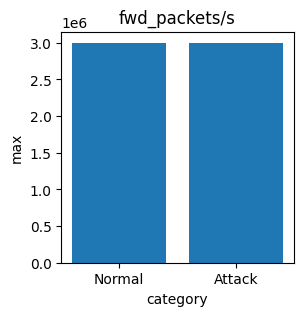

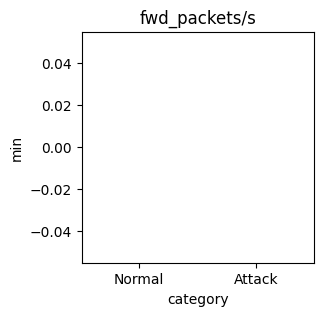

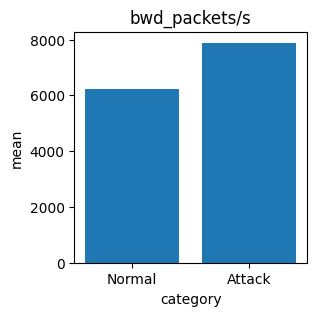

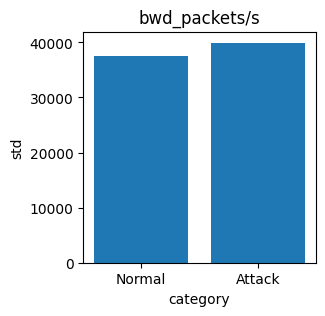

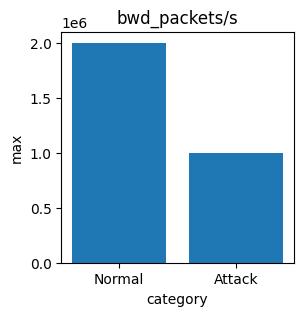

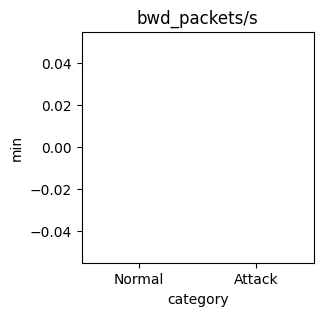

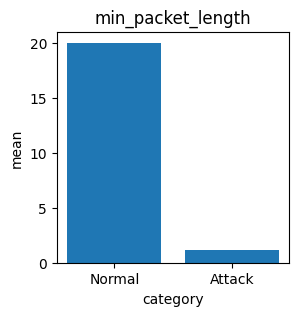

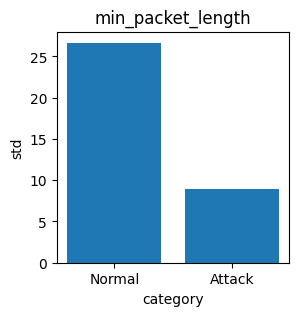

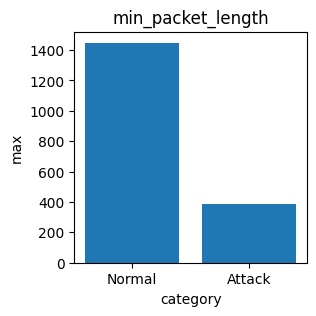

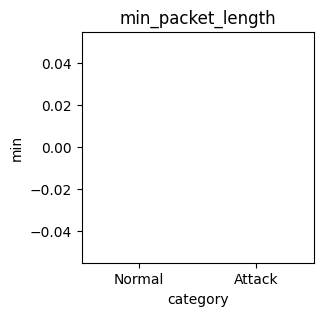

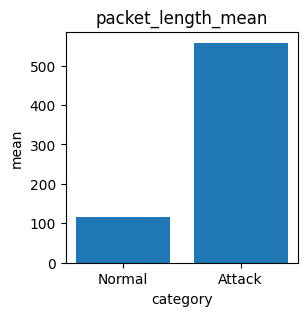

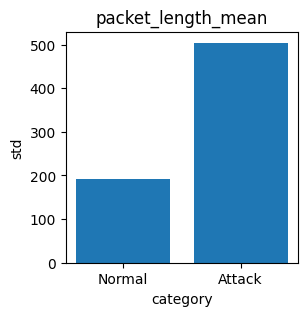

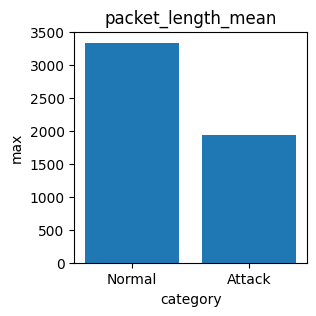

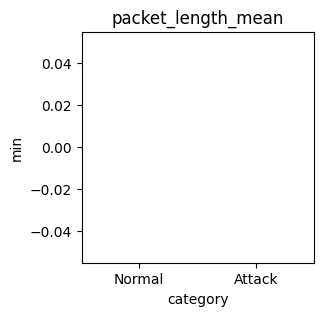

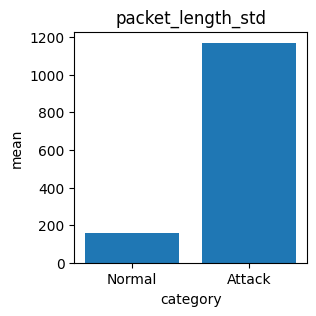

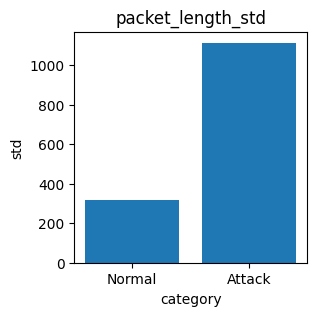

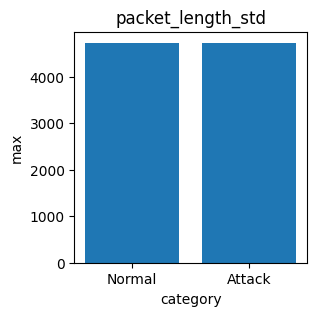

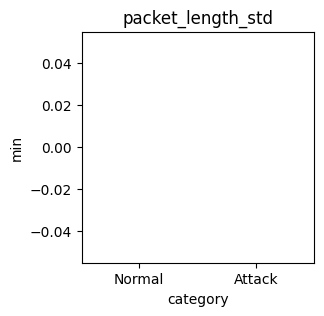

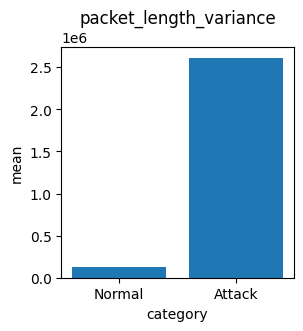

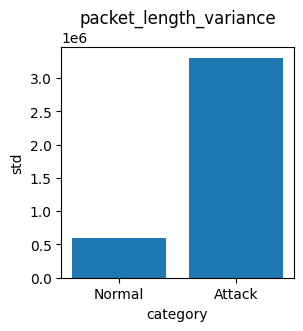

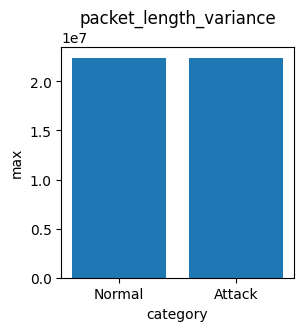

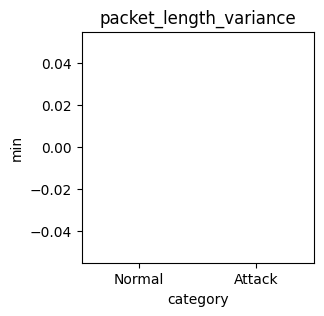

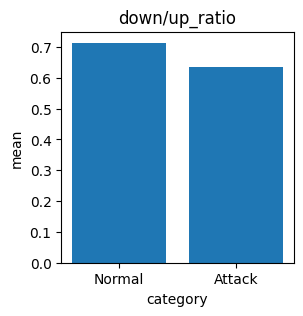

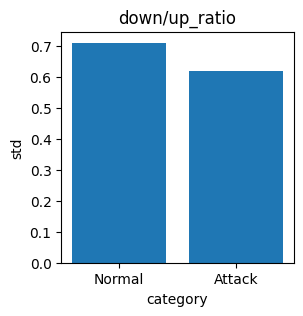

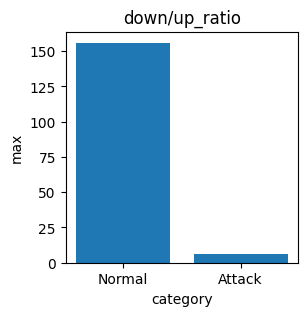

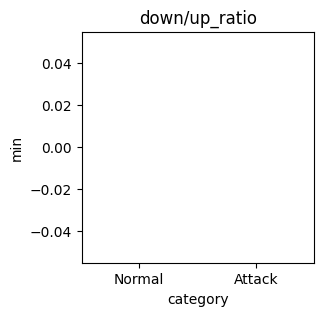

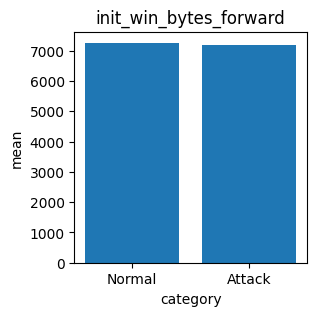

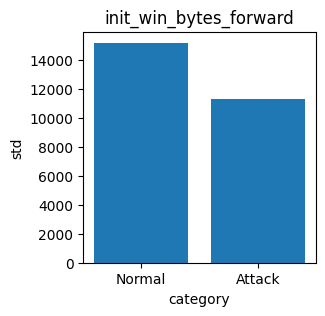

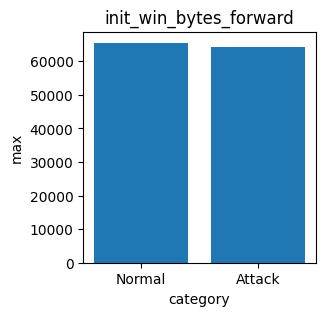

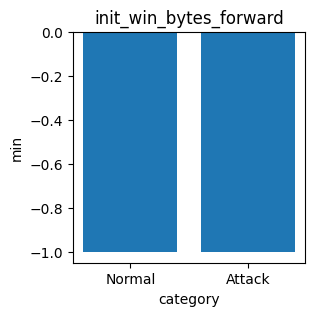

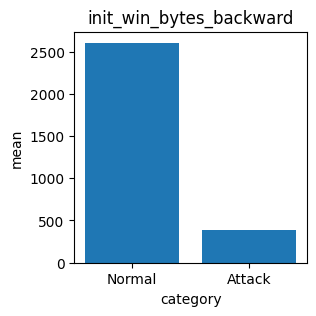

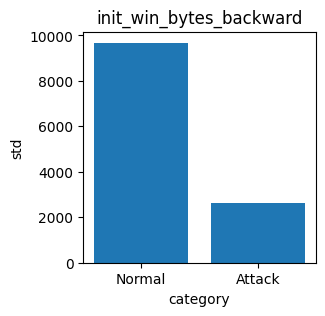

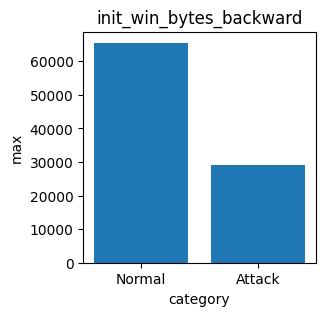

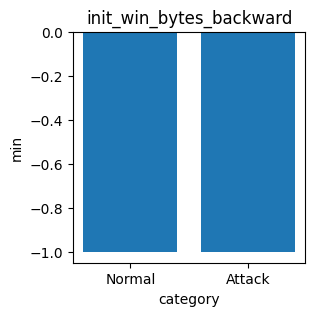

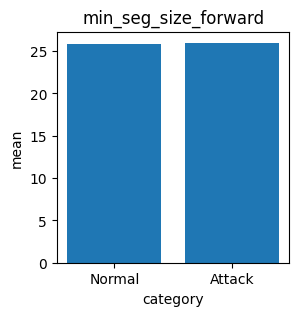

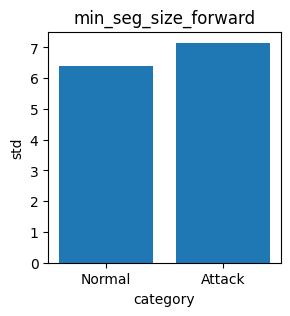

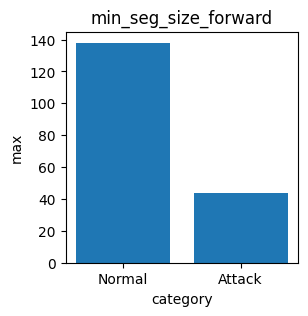

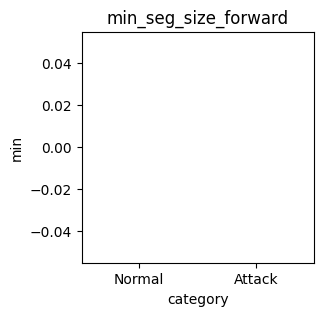

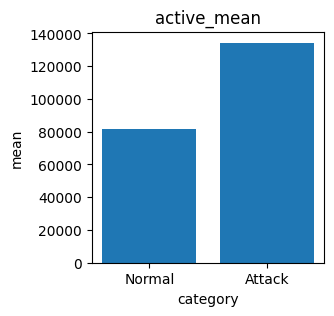

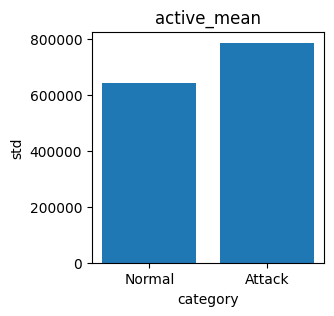

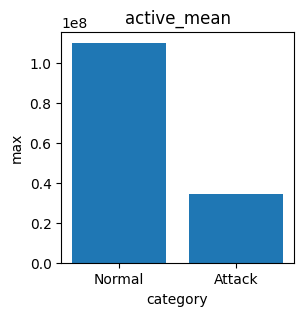

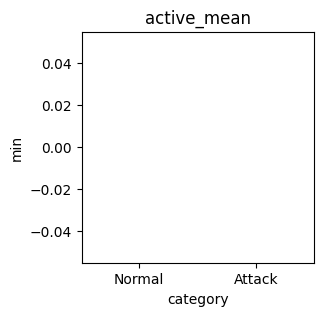

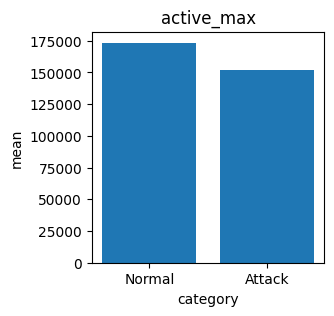

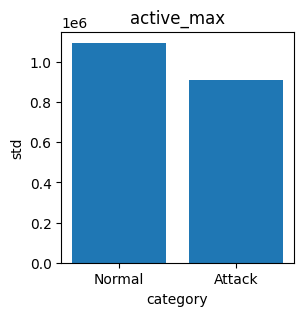

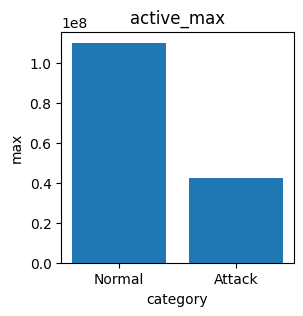

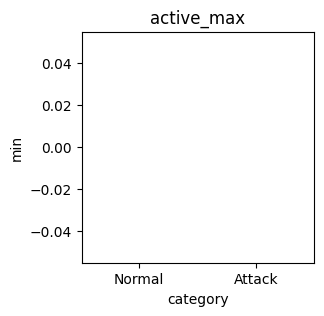

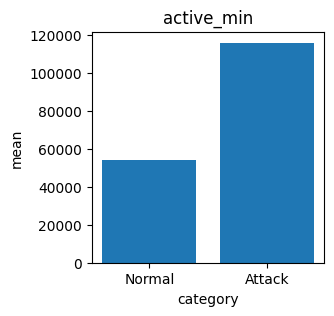

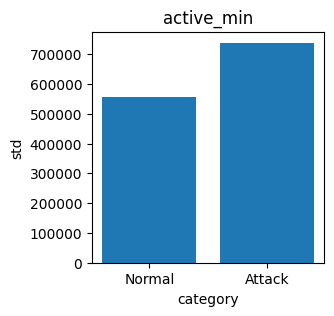

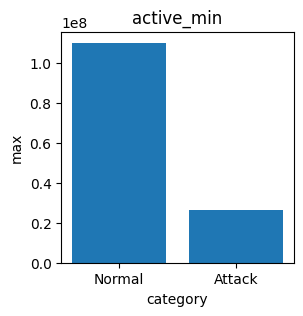

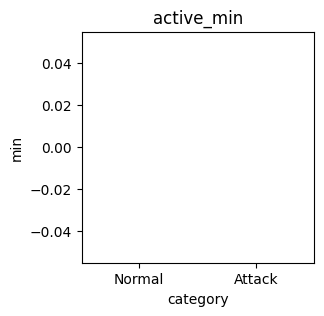

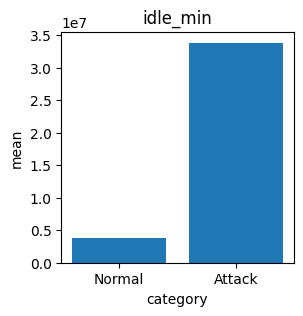

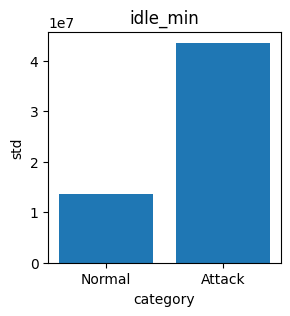

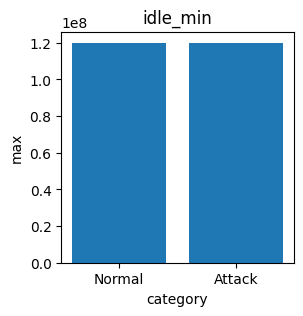

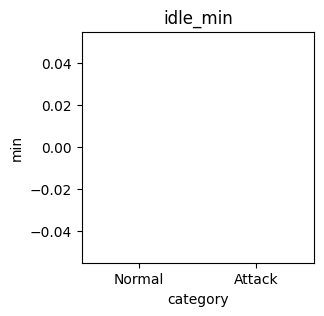

In [444]:
normals = cicids[cicids['binary_cat'] == 0][numerical_features].describe()
attacks = cicids[cicids['binary_cat'] == 1][numerical_features].describe()
for feature in normals.columns:
    for attr in ['mean', 'std', 'max', 'min']:
        plt.figure(figsize=(3, 3))
        plt.title(feature)
        plt.bar(['Normal', 'Attack'], [normals.loc[attr, feature], attacks.loc[attr, feature]])
        plt.xlabel('category')
        plt.ylabel(attr)
        plt.show()

In [450]:
"""
these features have high values in attacks unlike Benign:
bwd_packet_length, flow_iat, fwd_iat, bwd_iat, fwd_header_length, bwd_header_length, 
bwd_packets/s, max_packet_lenght, mean_packet_lenght, packet_length_std, average_packet_size, avg_bwd_segment_size,
act_mean, act_min, idle
"""

'\nthese features have high values in attacks unlike Benign:\nbwd_packet_length, flow_iat, fwd_iat, bwd_iat, fwd_header_length, bwd_header_length, \nbwd_packets/s, max_packet_lenght, mean_packet_lenght, packet_length_std, average_packet_size, avg_bwd_segment_size,\nact_mean, act_min, idle\n'

In [451]:
"""
this feature have the nearly same value in both attack and Benign:
init_win_bytes_forward
"""

'\nthis feature have the nearly same value in both attack and Benign:\ninit_win_bytes_forward\n'

# Preprocessing

## Split the data into training and testing

In [486]:
X = cicids.drop(columns = ['label', 'major_cat', 'sub_attack', 'binary_cat'])
Y = cicids[['label', 'major_cat', 'sub_attack', 'binary_cat']]
X_training, X_testing, Y_training, Y_testing = train_test_split(X, Y, test_size=0.3)

In [487]:
X_training.shape

(1763365, 48)

In [488]:
X_testing.shape

(755729, 48)

In [496]:
Y_training.shape

(1763365, 4)

In [497]:
Y_testing.shape

(755729, 4)

## Normalize the training and testing data

In [493]:
normalize = StandardScaler()
X_training_scaled = normalize.fit_transform(X_training)
X_training_scaled = pd.DataFrame(X_training_scaled, index = X_training.index, columns=X_training.columns)
X_testing_scaled = normalize.transform(X_testing)
X_testing_scaled = pd.DataFrame(X_testing_scaled, index = X_testing.index, columns=X_testing.columns)

In [494]:
X_training_scaled

,destination_port,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,bwd_packet_length_min,bwd_packet_length_mean,bwd_packet_length_std,flow_bytes/s,...,cwe_flag_count,ece_flag_count,down/up_ratio,init_win_bytes_forward,init_win_bytes_backward,min_seg_size_forward,active_mean,active_max,active_min,idle_min
471869,-0.454944,-0.049878,-0.018937,0.509693,-0.069145,-0.259833,1.549527,-0.294795,-0.426295,-0.053043,...,-0.005882,-0.016415,0.435229,-0.497204,-0.250172,-0.901871,-0.133811,-0.158502,-0.107225,-0.360759
2679748,-0.454944,-0.046738,-0.018526,0.377371,-0.110007,-0.259833,1.380184,-0.313807,-0.426295,0.011357,...,-0.005882,-0.016415,0.435229,-0.497204,-0.250172,-0.901871,-0.133811,-0.158502,-0.107225,-0.360759
1950474,-0.434449,-0.019224,-0.006249,-0.317318,-0.107737,-0.003225,-0.609591,0.553073,0.335075,-0.053118,...,-0.005882,-0.016415,-1.016066,1.506285,-0.211011,0.937690,-0.133811,-0.158502,-0.107225,-0.360759
724252,-0.451265,-0.045630,-0.019119,0.476612,-0.079361,-0.259833,0.067779,-0.461148,-0.426295,-0.053150,...,-0.005882,-0.016415,0.435229,-0.497204,-0.250172,-0.901871,-0.091285,-0.131725,-0.059451,2.449511
2282211,-0.434449,0.010414,-0.006821,-0.317318,0.074438,0.087072,-0.609591,0.031716,0.220867,-0.052935,...,-0.005882,-0.016415,0.435229,1.506285,-0.221641,0.937690,-0.133811,-0.158502,-0.107225,-0.360759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1400416,2.170148,-0.054125,-0.019387,-0.284237,-0.314316,-0.259833,-0.524920,-0.527688,-0.426295,-0.043823,...,-0.005882,-0.016415,0.435229,-0.426878,-0.250061,-0.288684,-0.133811,-0.158502,-0.107225,-0.360759
241261,-0.454944,-0.047477,-0.018092,0.311210,-0.130438,-0.259833,2.339792,-0.206074,-0.426295,0.040447,...,-0.005882,-0.016415,0.435229,-0.497204,-0.250172,2.777251,-0.133811,-0.158502,-0.107225,-0.360759
34189,-0.453525,-0.052094,0.017614,-0.317318,-0.280265,-0.225367,-0.609591,3.140616,4.585053,-0.049765,...,-0.005882,-0.016415,0.435229,0.064920,-0.224438,-0.901871,-0.133811,-0.158502,-0.107225,-0.360759
978883,-0.453525,-0.054494,-0.019426,-0.317318,-0.324532,-0.259833,-0.609591,-0.537194,-0.426295,-0.053150,...,-0.005882,-0.016415,-1.016066,1.506285,2.990251,0.937690,-0.133811,-0.158502,-0.107225,-0.360759


In [495]:
X_testing_scaled

,destination_port,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,bwd_packet_length_min,bwd_packet_length_mean,bwd_packet_length_std,flow_bytes/s,...,cwe_flag_count,ece_flag_count,down/up_ratio,init_win_bytes_forward,init_win_bytes_backward,min_seg_size_forward,active_mean,active_max,active_min,idle_min
2151277,-0.451265,-0.045630,-0.019119,0.476612,-0.079361,-0.259833,0.067779,-0.461148,-0.426295,-0.053150,...,-0.005882,-0.016415,0.435229,-0.497204,-0.250172,0.937690,-0.009252,-0.080070,0.032706,2.365115
1292963,-0.434449,0.054825,0.044819,-0.317318,-0.091934,0.226022,-0.609591,0.562643,0.391785,-0.053143,...,-0.005882,-0.016415,0.435229,1.506285,-0.211011,0.937690,-0.064765,-0.014828,-0.046027,-0.150918
2584714,2.420765,-0.028088,-0.019426,-0.218077,0.162405,0.259773,-0.609591,-0.537194,-0.426295,-0.037283,...,-0.005882,-0.016415,-1.016066,-0.493019,-0.250172,-0.901871,-0.133811,-0.158502,-0.107225,-0.360759
763479,-0.454944,-0.046738,-0.018896,1.072060,0.104517,-0.259833,1.732981,-0.274199,-0.426295,-0.034012,...,-0.005882,-0.016415,0.435229,-0.497204,-0.250172,-0.901871,-0.133811,-0.158502,-0.107225,-0.360759
1339514,-0.454944,-0.049785,-0.019081,0.526233,-0.064038,-0.259833,0.914492,-0.366089,-0.426295,-0.044840,...,-0.005882,-0.016415,0.435229,-0.497204,-0.250172,2.164064,-0.133811,-0.158502,-0.107225,-0.360759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1928772,-0.454944,-0.048400,-0.018602,0.228509,-0.155977,-0.259833,1.210842,-0.332819,-0.426295,-0.052889,...,-0.005882,-0.016415,0.435229,-0.497204,-0.250172,-0.901871,-0.133811,-0.158502,-0.107225,-0.360759
2799250,-0.454944,-0.040829,-0.018137,0.906658,0.053440,-0.259833,2.241009,-0.217164,-0.426295,0.043243,...,-0.005882,-0.016415,0.435229,-0.497204,-0.250172,-0.901871,-0.133811,-0.158502,-0.107225,-0.360759
1701047,-0.348843,-0.050986,-0.019426,-0.317318,-0.259834,-0.186157,-0.609591,-0.537194,-0.426295,-0.053110,...,-0.005882,-0.016415,-1.016066,-0.473053,-0.250061,-0.901871,-0.133811,-0.158502,-0.107225,-0.360759
734150,2.188489,-0.053386,-0.019426,-0.218077,-0.293885,-0.259833,-0.609591,-0.537194,-0.426295,-0.051256,...,-0.005882,-0.016415,-1.016066,-0.146262,-0.250172,-0.901871,-0.133811,-0.158502,-0.107225,-0.360759


In [501]:
Y_training['binary_cat']

471869     0
2679748    0
1950474    0
724252     0
2282211    0
          ..
1400416    0
241261     0
34189      1
978883     0
908726     0
Name: binary_cat, Length: 1763365, dtype: int64

In [502]:
Y_testing['binary_cat']

2151277    0
1292963    0
2584714    0
763479     0
1339514    0
          ..
1928772    0
2799250    0
1701047    0
734150     0
2789122    0
Name: binary_cat, Length: 755729, dtype: int64

# Build Model Detection

In [514]:
Model1 = XGBClassifier(
    random_state=42,
)

In [515]:
Model1.fit(X_training_scaled, Y_training['binary_cat'])

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [516]:
Y_predicting = Model1.predict(X_testing_scaled)

In [517]:
accuracy = accuracy_score(Y_testing['binary_cat'], Y_predicting)
print(accuracy)

0.9991782768690893


In [520]:
print(classification_report(Y_testing['binary_cat'], Y_predicting))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    627599
           1       1.00      1.00      1.00    128130

    accuracy                           1.00    755729
   macro avg       1.00      1.00      1.00    755729
weighted avg       1.00      1.00      1.00    755729



# Preprocessing

## Drop benign category and take only attacks

In [668]:
cicids2 = cicids[cicids['major_cat'] != 'benign']
X2 = cicids2.drop(columns = ['label', 'major_cat', 'sub_attack', 'binary_cat'])
Y2 = cicids2[['label', 'major_cat', 'sub_attack', 'binary_cat']]

## Split the data into training and testing

In [669]:
X_training2, X_testing2, Y_training2, Y_testing2 = train_test_split(X2, Y2, test_size=0.3, stratify=Y2['major_cat'])
# X_training2, X_testing2, Y_training2, Y_testing2 = train_test_split(X2, Y2, test_size=0.3)

In [670]:
# print(cicids2['major_cat'].value_counts())
# heartbleed_rows = cicids2[cicids2['major_cat'] == 'heartbleed']
# heartbleed_rows_samples = heartbleed_rows.sample(replace=True, n=43)
# cicids2 = pd.concat([cicids2, heartbleed_rows_samples], ignore_index=True)

In [671]:
Y_training2['major_cat'].value_counts()

major_cat
dos             135507
ddos             89598
port-scan        63573
brute-force       6402
web-attack        1500
bot               1367
infiltration        25
heartbleed           5
Name: count, dtype: int64

In [672]:
Y_testing2['major_cat'].value_counts()

major_cat
dos             58075
ddos            38399
port-scan       27246
brute-force      2744
web-attack        643
bot               586
infiltration       10
heartbleed          2
Name: count, dtype: int64

## Encoding the output for classification

In [673]:
encode = LabelEncoder()
Y_training2_encoded = encode.fit_transform(Y_training2['major_cat'])
Y_testing2_encoded = encode.transform(Y_testing2['major_cat'])

In [674]:
Y_training2_encoded

array([6, 2, 2, ..., 2, 3, 3], shape=(297977,))

In [675]:
Y_testing2_encoded

array([2, 3, 3, ..., 1, 3, 2], shape=(127705,))

## Normalize the features

In [676]:
normalize2 = StandardScaler()
X_training2_scaled = normalize2.fit_transform(X_training2)
X_testing2_scaled = normalize2.transform(X_testing2)

In [677]:
X_training2_scaled

array([[ 0.01918596, -0.03088226, -0.23008578, ..., -0.16790049,
        -0.15747268, -0.77704219],
       [-0.2587705 , -0.02784458,  0.16578291, ..., -0.16790049,
        -0.15747268, -0.77704219],
       [-0.2587705 , -0.02784458,  0.16557817, ..., -0.16790049,
        -0.15747268, -0.77704219],
       ...,
       [-0.2587705 , -0.02784458,  0.16578291, ..., -0.16790049,
        -0.15747268, -0.77704219],
       [-0.2587705 ,  0.01690282,  0.16537342, ..., -0.16681193,
        -0.15613719,  1.1627875 ],
       [-0.2587705 ,  0.0123463 ,  0.16537342, ..., -0.15470575,
        -0.14128486,  1.13297924]], shape=(297977, 48))

In [678]:
X_testing2_scaled

array([[-0.2587705 , -0.02784458,  0.16578291, ..., -0.16790049,
        -0.15747268, -0.77704219],
       [-0.2587705 ,  0.00720561,  0.16537342, ..., -0.15579651,
        -0.14262305,  1.15590867],
       [-0.2587705 ,  0.00767294,  0.16537342, ..., -0.16681303,
        -0.15613854,  1.48150656],
       ...,
       [-0.26687699, -0.0200167 , -0.22387527, ..., -0.16790049,
        -0.15747268, -0.77704219],
       [-0.2587705 , -0.02877925, -0.23029052, ..., -0.16790049,
        -0.15747268, -0.77704219],
       [-0.2587705 , -0.02784458,  0.16578291, ..., -0.16790049,
        -0.15747268, -0.77704219]], shape=(127705, 48))

# Build Model Classification

In [679]:
Model2 = XGBClassifier(
    random_state=42,
    num_class = len(encode.classes_),
    objective='multi:softmax'
)

In [680]:
Model2.fit(X_training2_scaled, Y_training2_encoded)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn

In [681]:
Y_predicting2 = Model2.predict(X_testing2_scaled)

In [682]:
accuracy2 = accuracy_score(Y_testing2_encoded, Y_predicting2)
print(accuracy2)

0.9997102697623429


In [683]:
print(classification_report(Y_testing2_encoded, Y_predicting2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       586
           1       1.00      1.00      1.00      2744
           2       1.00      1.00      1.00     38399
           3       1.00      1.00      1.00     58075
           4       1.00      1.00      1.00         2
           5       1.00      0.70      0.82        10
           6       1.00      1.00      1.00     27246
           7       0.98      0.99      0.99       643

    accuracy                           1.00    127705
   macro avg       1.00      0.96      0.98    127705
weighted avg       1.00      1.00      1.00    127705



In [684]:
encode.classes_

array(['bot', 'brute-force', 'ddos', 'dos', 'heartbleed', 'infiltration',
       'port-scan', 'web-attack'], dtype=object)

In [685]:
Model3 = XGBClassifier(
    objective='multi:softmax', 
    num_class=len(encode.classes_), 
    random_state=42
)

sample_weights = compute_sample_weight(class_weight='balanced', y=Y_training2_encoded)

In [686]:
Model3.fit(X_training2_scaled, Y_training2_encoded, sample_weight=sample_weights)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn

In [687]:
Y_predicting3 = Model3.predict(X_testing2_scaled)
accuracy3 = accuracy_score(Y_testing2_encoded, Y_predicting3)
print(accuracy3)

0.9997572530441251


In [688]:
print(classification_report(Y_testing2_encoded, Y_predicting3))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       586
           1       1.00      1.00      1.00      2744
           2       1.00      1.00      1.00     38399
           3       1.00      1.00      1.00     58075
           4       1.00      1.00      1.00         2
           5       1.00      0.70      0.82        10
           6       1.00      1.00      1.00     27246
           7       0.98      1.00      0.99       643

    accuracy                           1.00    127705
   macro avg       1.00      0.96      0.98    127705
weighted avg       1.00      1.00      1.00    127705



# Preprocessing

In [719]:
X3 = cicids.drop(columns = ['label', 'major_cat', 'sub_attack', 'binary_cat'])
Y3 = cicids[['label', 'major_cat', 'sub_attack', 'binary_cat']]

In [720]:
X_training3, X_testing3, Y_training3, Y_testing3 = train_test_split(X3, Y3, test_size=0.3, stratify=Y3['major_cat'])

In [721]:
Y_training3['major_cat'].value_counts()

major_cat
benign          1465388
dos              135507
ddos              89598
port-scan         63573
brute-force        6402
web-attack         1500
bot                1367
infiltration         25
heartbleed            5
Name: count, dtype: int64

In [722]:
Y_testing3['major_cat'].value_counts()

major_cat
benign          628024
dos              58075
ddos             38399
port-scan        27246
brute-force       2744
web-attack         643
bot                586
infiltration        10
heartbleed           2
Name: count, dtype: int64

## Encoding the output for classification

In [723]:
encode2 = LabelEncoder()
Y_training3_encoded = encode2.fit_transform(Y_training3['major_cat'])
Y_testing3_encoded = encode2.transform(Y_testing3['major_cat'])

In [724]:
Y_training3_encoded

array([0, 7, 4, ..., 0, 0, 0], shape=(1763365,))

In [725]:
Y_testing3_encoded

array([4, 0, 0, ..., 0, 0, 0], shape=(755729,))

## Normalize the features

In [726]:
normalize3 = StandardScaler()
X_training3_scaled = normalize3.fit_transform(X_training3)
X_testing3_scaled = normalize3.transform(X_testing3)

In [727]:
X_training3_scaled

array([[-0.45351946, -0.01888297, -0.06526534, ..., -0.03489012,
         0.11550668,  0.04639831],
       [ 0.91957438, -0.05374215, -0.06774945, ..., -0.15899583,
        -0.10987648, -0.36090673],
       [-0.45351946, -0.01025991, -0.02670914, ..., -0.15812678,
        -0.10829824, -0.11106005],
       ...,
       [-0.43444726,  0.09743662, -0.05501401, ..., -0.15899583,
        -0.10987648, -0.36090673],
       [-0.43444726,  0.12367274, -0.00359409, ..., -0.15899583,
        -0.10987648, -0.36090673],
       [ 2.41734687, -0.05264134, -0.06781942, ..., -0.15899583,
        -0.10987648, -0.36090673]], shape=(1763365, 48))

In [728]:
X_testing3_scaled

array([[-0.45351946, -0.02328624,  0.06740715, ..., -0.15715847,
        -0.10653971,  3.71246022],
       [-0.45661935, -0.05374215, -0.06767947, ..., -0.15899583,
        -0.10987648, -0.36090673],
       [-0.43444726, -0.05264134, -0.06781942, ..., -0.15899583,
        -0.10987648, -0.36090673],
       ...,
       [-0.45493806, -0.04548603, -0.0663966 , ..., -0.15899583,
        -0.10987648, -0.36090673],
       [-0.45493806, -0.04860501, -0.065277  , ..., -0.15899583,
        -0.10987648, -0.36090673],
       [-0.45493806, -0.04961409, -0.06654821, ..., -0.15899583,
        -0.10987648, -0.36090673]], shape=(755729, 48))

# Build Model Detection & Classification

In [729]:
Model4 = XGBClassifier(
    objective='multi:softmax', 
    num_class=len(encode.classes_), 
    random_state=42
)

sample_weights = compute_sample_weight(class_weight='balanced', y=Y_training3_encoded)

In [730]:
Model4.fit(X_training3_scaled, Y_training3_encoded, sample_weight=sample_weights)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn

In [732]:
Y_predicting4 = Model4.predict(X_testing3_scaled)
accuracy4 = accuracy_score(Y_testing3_encoded, Y_predicting4)
print(accuracy4)

0.9989123085127076


In [733]:
print(classification_report(Y_testing3_encoded, Y_predicting4))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    628024
           1       0.65      1.00      0.78       586
           2       1.00      1.00      1.00      2744
           3       1.00      1.00      1.00     38399
           4       1.00      1.00      1.00     58075
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00        10
           7       0.99      1.00      0.99     27246
           8       0.98      0.99      0.99       643

    accuracy                           1.00    755729
   macro avg       0.96      1.00      0.97    755729
weighted avg       1.00      1.00      1.00    755729

